### LADEN
  1. Daten laden (eine Station, nur Diesel)
  2. Stationsdaten mergen

### QUALITÄTSKONTROLLE
  3. Nach Zeit sortieren
  4. Duplikate bereinigen
  5. NaN interpolieren
  6. Ausreißer bereinigen

### EDA
  7. Grobe EDA zur Plausibilisierung

### FEATURE ENGINEERING
  8. Features berechnen
  9. Finales Feature-Set prüfen (Korrelation)
 10. Überflüssige Spalten droppen
 11. Speichern

### SPLIT + MODELLE
 12. Train/Val/Test Split
 13. Modell 1 — Herleitung + Training
 14. Modell 2 — Herleitung + Training
 15. Modell 3 — Herleitung + Training
 16. Parametertuning bestes Modell
 17. Modellvergleich + finale Auswahl + speichern

### LIVE-PIPELINE
 18. Features aus GitHub Actions Workflows laden
 19. Prognose ausführen

In [52]:
# =========================================
# Zelle 1: Daten laden — ARAL Dürener Str. 407, nur Diesel
# =========================================
import pandas as pd
import gc
import ctypes
import psutil

def ram_freigeben(label=""):
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)
    mb = psutil.Process().memory_info().rss / 1e6
    print(f"[RAM] {label}: {mb:.0f} MB")

STATION_UUID = "e1aefc4e-3ca1-4018-8d91-455b69d35d41"

df_raw = pd.read_parquet("../data/ml/ml_master_dataset.parquet")

df = df_raw[
    (df_raw["station_uuid"] == STATION_UUID) &
    (df_raw["kraftstoff"]   == "diesel")
].copy()

del df_raw
ram_freigeben("nach Filter")

print(f"Shape:    {df.shape}")
print(f"Zeitraum: {df['date'].min()} → {df['date'].max()}")
display(df.head())

[RAM] nach Filter: 2830 MB
Shape:    (78079, 27)
Zeitraum: 2017-06-09 11:52:06 → 2026-03-19 21:07:02


,date,station_uuid,kraftstoff,preis,jahr,quartal,monat,tag,stunde,wochentag,...,brent_usd,eur_usd,co2_preis_eur_t,energiesteuer_benzin,energiesteuer_diesel,ist_tankrabatt,ist_lockdown,ist_niedrigwasser,ist_schulferien_nrw,ist_feiertag_nrw
746027,2017-06-09 22:01:06,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.219,2017,2,6,9,22,4,...,48.150002,1.1176,0.0,65.449997,47.040001,False,False,False,False,False
746050,2017-06-09 11:52:06,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.099,2017,2,6,9,11,4,...,48.150002,1.1176,0.0,65.449997,47.040001,False,False,False,False,False
746052,2017-06-09 12:18:07,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.099,2017,2,6,9,12,4,...,48.150002,1.1176,0.0,65.449997,47.040001,False,False,False,False,False
746053,2017-06-09 13:37:07,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.089,2017,2,6,9,13,4,...,48.150002,1.1176,0.0,65.449997,47.040001,False,False,False,False,False
746054,2017-06-09 16:08:06,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.079,2017,2,6,9,16,4,...,48.150002,1.1176,0.0,65.449997,47.040001,False,False,False,False,False


In [53]:
# =========================================
# Zelle 2: Stationsdaten mergen
# =========================================

stationen = (
    pd.read_parquet(
        "../data/ml/analysis_dataset.parquet",
        columns=["station_uuid", "brand", "street",
                 "latitude", "longitude", "distanz_km", "post_code"]
    )
    .drop_duplicates(subset="station_uuid")
)
stationen["brand"] = stationen["brand"].str.strip()

df = df.merge(stationen, on="station_uuid", how="left")

del stationen
ram_freigeben("nach Merge")

print(f"Shape:   {df.shape}")
print(f"Spalten: {df.columns.tolist()}")
display(df.head())

[RAM] nach Merge: 3314 MB
Shape:   (78079, 33)
Spalten: ['date', 'station_uuid', 'kraftstoff', 'preis', 'jahr', 'quartal', 'monat', 'tag', 'stunde', 'wochentag', 'ist_wochenende', 'date_day', 'temp_avg', 'temp_min', 'temp_max', 'niederschlag_mm', 'sonnenstunden', 'brent_usd', 'eur_usd', 'co2_preis_eur_t', 'energiesteuer_benzin', 'energiesteuer_diesel', 'ist_tankrabatt', 'ist_lockdown', 'ist_niedrigwasser', 'ist_schulferien_nrw', 'ist_feiertag_nrw', 'brand', 'street', 'latitude', 'longitude', 'distanz_km', 'post_code']


,date,station_uuid,kraftstoff,preis,jahr,quartal,monat,tag,stunde,wochentag,...,ist_lockdown,ist_niedrigwasser,ist_schulferien_nrw,ist_feiertag_nrw,brand,street,latitude,longitude,distanz_km,post_code
0,2017-06-09 22:01:06,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.219,2017,2,6,9,22,4,...,False,False,False,False,ARAL,Dürener Straße,50.919537,6.852624,0.000044,50858
1,2017-06-09 11:52:06,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.099,2017,2,6,9,11,4,...,False,False,False,False,ARAL,Dürener Straße,50.919537,6.852624,0.000044,50858
2,2017-06-09 12:18:07,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.099,2017,2,6,9,12,4,...,False,False,False,False,ARAL,Dürener Straße,50.919537,6.852624,0.000044,50858
3,2017-06-09 13:37:07,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.089,2017,2,6,9,13,4,...,False,False,False,False,ARAL,Dürener Straße,50.919537,6.852624,0.000044,50858
4,2017-06-09 16:08:06,e1aefc4e-3ca1-4018-8d91-455b69d35d41,diesel,1.079,2017,2,6,9,16,4,...,False,False,False,False,ARAL,Dürener Straße,50.919537,6.852624,0.000044,50858


In [54]:
# =========================================
# Zelle 3: Nach Zeit sortieren
# =========================================

df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape:    {df.shape}")
print(f"Zeitraum: {df['date'].min()} → {df['date'].max()}")
print(f"Sortierung korrekt: {df['date'].is_monotonic_increasing}")

Shape:    (78079, 33)
Zeitraum: 2017-06-09 11:52:06 → 2026-03-19 21:07:02
Sortierung korrekt: True


In [55]:
# =========================================
# Zelle 3b: Trainingszeitraum begrenzen
# =========================================
# Cut-off 28.02.2026 — Iran-Krieg / Hormuz-Blockade ab März 2026
# ist ein struktureller Bruch der nicht Teil des Trainings sein soll.

zeilen_vorher = len(df)
df = df[df["date"] <= "2026-02-28"].copy()
df.reset_index(drop=True, inplace=True)

print(f"Zeilen vorher:  {zeilen_vorher:,}")
print(f"Zeilen nachher: {len(df):,}")
print(f"Entfernt:       {zeilen_vorher - len(df):,}")
print(f"Zeitraum: {df['date'].min()} → {df['date'].max()}")

Zeilen vorher:  78,079
Zeilen nachher: 77,343
Entfernt:       736
Zeitraum: 2017-06-09 11:52:06 → 2026-01-31 21:31:47


In [56]:
# =========================================
# Zelle 4: Duplikate bereinigen
# =========================================

zeilen_vorher = len(df)
duplikate = df.duplicated(subset="date", keep=False)
print(f"Doppelte Timestamps: {duplikate.sum()}")
display(df[duplikate][["date", "preis"]].head(10))

# Mittelwert bei gleichem Timestamp
df = (
    df.groupby("date", as_index=False)
    .agg({
        col: "mean" if df[col].dtype in ["float32", "float64"] else "first"
        for col in df.columns
        if col != "date"
    })
)

df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)
ram_freigeben("nach Deduplizierung")

print(f"Zeilen vorher:  {zeilen_vorher:,}")
print(f"Zeilen nachher: {len(df):,}")
print(f"Entfernt:       {zeilen_vorher - len(df):,}")

Doppelte Timestamps: 0


,date,preis


[RAM] nach Deduplizierung: 3309 MB
Zeilen vorher:  77,343
Zeilen nachher: 77,343
Entfernt:       0


In [57]:
# =========================================
# Zelle 5: NaN interpolieren
# =========================================

print("NaN vor Interpolation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["preis"] = df["preis"].interpolate(method="linear", limit_direction="both")

print(f"\nNaN nach Interpolation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"Gesamt NaN: {df.isnull().sum().sum()}")

NaN vor Interpolation:
Series([], dtype: int64)

NaN nach Interpolation:
Series([], dtype: int64)
Gesamt NaN: 0


In [58]:
# =========================================
# Zelle 6: Ausreißer bereinigen
# =========================================

q1 = df["preis"].quantile(0.25)
q3 = df["preis"].quantile(0.75)
iqr = q3 - q1
untergrenze = q1 - 1.5 * iqr
obergrenze  = q3 + 1.5 * iqr

ausreisser = df[(df["preis"] < untergrenze) | (df["preis"] > obergrenze)]
print(f"Untergrenze: {untergrenze:.3f} €")
print(f"Obergrenze:  {obergrenze:.3f} €")
print(f"Ausreißer:   {len(ausreisser):,} Zeilen ({len(ausreisser)/len(df)*100:.2f}%)")
display(ausreisser[["date", "preis"]].head(10))

df.loc[(df["preis"] < untergrenze) | (df["preis"] > obergrenze), "preis"] = None
df["preis"] = df["preis"].interpolate(method="linear", limit_direction="both")

print(f"\nNaN nach Bereinigung: {df['preis'].isna().sum()}")
print(f"Preis-Bereich: {df['preis'].min():.3f} € — {df['preis'].max():.3f} €")

Untergrenze: 0.714 €
Obergrenze:  2.274 €
Ausreißer:   150 Zeilen (0.19%)


,date,preis
32316,2022-03-09 09:06:01,2.299
32317,2022-03-09 09:36:01,2.299
32318,2022-03-09 09:56:01,2.299
32319,2022-03-09 10:36:01,2.279
32320,2022-03-09 10:51:01,2.279
32323,2022-03-09 12:11:01,2.299
32324,2022-03-09 12:21:01,2.299
32325,2022-03-09 12:41:01,2.299
32326,2022-03-09 13:31:01,2.299
32327,2022-03-09 13:56:01,2.299



NaN nach Bereinigung: 0
Preis-Bereich: 0.979 € — 2.269 €


Anzahl Preisänderungen gesamt: 60,387
Ø Preisänderungen pro Tag:     19.1

Preis Min:  0.979 €
Preis Max:  2.269 €
Preis Mean: 1.532 €
Preis Std:  0.264 €


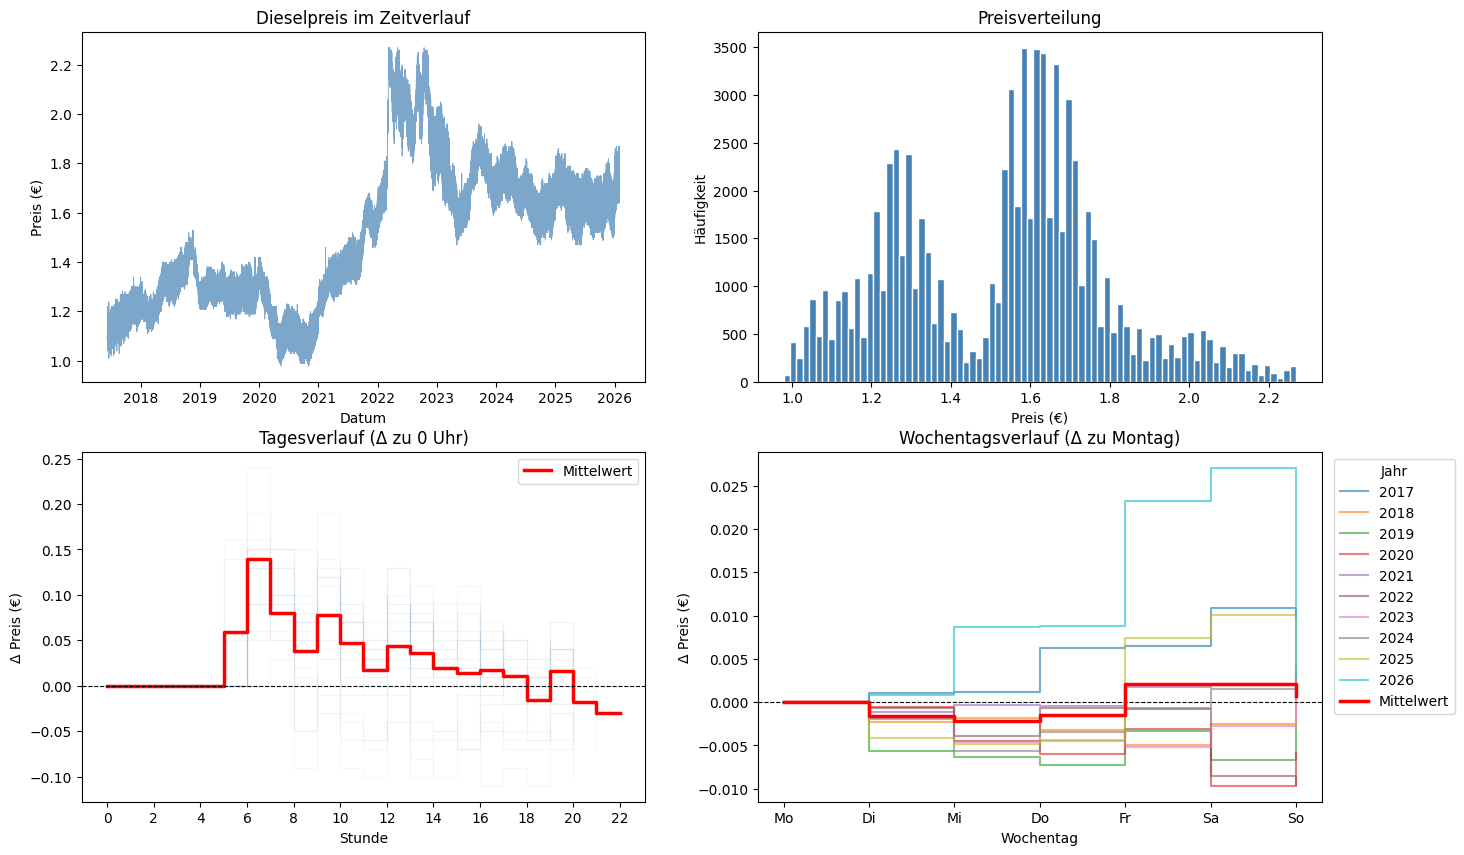

In [59]:
# =========================================
# Zelle 7: EDA — Plausibilisierung
# =========================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Preisverlauf gesamt ---
axes[0][0].plot(df["date"], df["preis"], color="steelblue", linewidth=0.6, alpha=0.7)
axes[0][0].set_title("Dieselpreis im Zeitverlauf")
axes[0][0].set_xlabel("Datum")
axes[0][0].set_ylabel("Preis (€)")

# --- Plot 2: Preisverteilung ---
axes[0][1].hist(df["preis"], bins=80, color="steelblue", edgecolor="white")
axes[0][1].set_title("Preisverteilung")
axes[0][1].set_xlabel("Preis (€)")
axes[0][1].set_ylabel("Häufigkeit")

# --- Plot 3: Tagesverlauf normalisiert auf 0 Uhr ---
# Pro Tag: Δ zu 0-Uhr-Preis, dann Mittelwert über alle Tage
df["stunde"]   = df["date"].dt.hour
df["date_day"] = df["date"].dt.date

tages_basis = (
    df[df["stunde"] == 0]
    .groupby("date_day")["preis"]
    .mean()
    .rename("basis")
)
df_norm = df.join(tages_basis, on="date_day")
df_norm["preis_norm"] = df_norm["preis"] - df_norm["basis"]

# Pro Tag einzeln plotten, dann Mittelwert drüber
for tag in df_norm["date_day"].unique():
    tag_df = df_norm[df_norm["date_day"] == tag].sort_values("stunde")
    axes[1][0].step(tag_df["stunde"], tag_df["preis_norm"],
                    where="post", color="steelblue", alpha=0.05, linewidth=0.8)

stunden_mittel = df_norm.groupby("stunde")["preis_norm"].mean()
axes[1][0].step(stunden_mittel.index, stunden_mittel.values,
                where="post", color="red", linewidth=2.5, label="Mittelwert")
axes[1][0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1][0].set_title("Tagesverlauf (Δ zu 0 Uhr)")
axes[1][0].set_xlabel("Stunde")
axes[1][0].set_ylabel("Δ Preis (€)")
axes[1][0].set_xticks(range(0, 24, 2))
axes[1][0].legend()

# --- Plot 4: Wochentagsverlauf normalisiert auf Montag ---
df["wochentag"] = df["date"].dt.dayofweek
df["kw"]        = df["date"].dt.isocalendar().week.astype(int)
df["jahr"]      = df["date"].dt.year

wt_basis = (
    df[df["wochentag"] == 0]
    .groupby(["jahr", "kw"])["preis"]
    .mean()
    .rename("basis_mo")
)
df_wt = df.join(wt_basis, on=["jahr", "kw"])
df_wt["preis_norm"] = df_wt["preis"] - df_wt["basis_mo"]

# Schritt 1: Pro Woche normalisieren, dann pro Jahr + Wochentag mitteln
jahres_wt_mittel = (
    df_wt.groupby(["jahr", "kw", "wochentag"])["preis_norm"]
    .mean()
    .groupby(["jahr", "wochentag"])
    .mean()
    .reset_index()
)

# Schritt 2: Eine Linie pro Jahr
for jahr, gruppe in jahres_wt_mittel.groupby("jahr"):
    wt_df = gruppe.set_index("wochentag")["preis_norm"].reindex(range(7))
    axes[1][1].step(wt_df.index, wt_df.values,
                    where="post", linewidth=1.5, alpha=0.6, label=str(jahr))

# Schritt 3: Gesamtmittelwert über alle Jahre
gesamtmittel = jahres_wt_mittel.groupby("wochentag")["preis_norm"].mean().reindex(range(7))
axes[1][1].step(gesamtmittel.index, gesamtmittel.values,
                where="post", color="red", linewidth=2.5, label="Mittelwert", zorder=5)
axes[1][1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1][1].set_title("Wochentagsverlauf (Δ zu Montag)")
axes[1][1].set_xlabel("Wochentag")
axes[1][1].set_ylabel("Δ Preis (€)")
axes[1][1].set_xticks(range(7))
axes[1][1].set_xticklabels(["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"])
axes[1][1].legend(title="Jahr", bbox_to_anchor=(1.01, 1), loc="upper left")

# Aufräumen
del df_norm, df_wt
df.drop(columns=["stunde", "date_day", "wochentag", "kw", "jahr"],
        errors="ignore", inplace=True)

print(f"Anzahl Preisänderungen gesamt: {(df['preis'].diff() != 0).sum():,}")
print(f"Ø Preisänderungen pro Tag:     {(df['preis'].diff() != 0).sum() / df['date'].dt.date.nunique():.1f}")
print(f"\nPreis Min:  {df['preis'].min():.3f} €")
print(f"Preis Max:  {df['preis'].max():.3f} €")
print(f"Preis Mean: {df['preis'].mean():.3f} €")
print(f"Preis Std:  {df['preis'].std():.3f} €")

## EDA — Beobachtungen

### Tagesverlauf (Δ zu 0 Uhr)
- Klares Tagesmuster: Preise steigen ab ca. 6 Uhr morgens an
- Plateau tagsüber zwischen 8 und 18 Uhr
- Leichter Rückgang ab ca. 20 Uhr
- Signal ist konsistent über alle Jahre → taugliches Feature

### Wochentagsverlauf (Δ zu Montag)
- Effekt sehr klein (~0.01%) — kaum nutzbares Signal
- 2026 (nur Januar/Februar) ist ein Ausreißer und verzerrt das Bild
- Wochentag als Feature kritisch hinterfragen

### Preisverteilung
- Bimodale Verteilung: zwei klare Preisniveaus
  - 1,20–1,40 € → vor Ukraine-Krieg (2017–2021)
  - 1,60–1,80 € → nach Ukraine-Krieg (2022–2025)
- Kein normalverteiltes Preisniveau → Modell muss mit Strukturbrüchen umgehen können

In [92]:
# =========================================
# Zelle 8: Stundenbins bilden
# =========================================
# Sekündliche Preismeldungen → ein Mittelwert pro Stunde.
# Damit wird die Zeitreihe regelmäßig (1 Zeile = 1 Stunde).

df["stunde_bin"] = df["date"].dt.floor("h")

df_std = (
    df.groupby("stunde_bin")
    .agg(
        preis           = ("preis",               "mean"),
        brent_usd       = ("brent_usd",           "first"),
        eur_usd         = ("eur_usd",             "first"),
        ist_feiertag    = ("ist_feiertag_nrw",    "first"),
        ist_schulferien = ("ist_schulferien_nrw", "first"),
    )
    .reset_index()
    .rename(columns={"stunde_bin": "date"})
)

# Lücken füllen — fehlende Stunden mit letztem bekannten Wert
df_std = df_std.set_index("date").asfreq("h").reset_index()
df_std["preis"]           = df_std["preis"].ffill()
df_std["brent_usd"]       = df_std["brent_usd"].ffill()
df_std["eur_usd"]         = df_std["eur_usd"].ffill()
df_std["ist_feiertag"]    = df_std["ist_feiertag"].ffill().fillna(0).astype(int)
df_std["ist_schulferien"] = df_std["ist_schulferien"].ffill().fillna(0).astype(int)

ram_freigeben("nach Stundenbins")

print(f"Shape:    {df_std.shape}")
print(f"Zeitraum: {df_std['date'].min()} → {df_std['date'].max()}")
print(f"NaN:      {df_std.isnull().sum().sum()}")

[RAM] nach Stundenbins: 2114 MB
Shape:    (75803, 6)
Zeitraum: 2017-06-09 11:00:00 → 2026-01-31 21:00:00
NaN:      0


In [93]:
# =========================================
# Zelle 9: Zielvariable — Stundenmittel nächste 24h minus letzte 24h
# =========================================

df_std = df_std.sort_values("date").reset_index(drop=True)

# Mittelwert der letzten 24h (inkl. aktuelle Stunde)
df_std["mean_24h_rueck"] = df_std["preis"].rolling(24, min_periods=24).mean()

# Mittelwert der nächsten 24h
df_std["mean_24h_vor"] = (
    df_std["preis"]
    .iloc[::-1]
    .rolling(24, min_periods=24)
    .mean()
    .iloc[::-1]
    .shift(-24)
)

# Zielvariable: Delta und Richtung
df_std["delta_24h"]    = df_std["mean_24h_vor"] - df_std["mean_24h_rueck"]
df_std["richtung_24h"] = (df_std["delta_24h"] > 0).astype(int)

# NaN entfernen
zeilen_vorher = len(df_std)
df_std.dropna(subset=["delta_24h", "mean_24h_rueck"], inplace=True)
df_std.reset_index(drop=True, inplace=True)

print(f"Zeilen vorher:  {zeilen_vorher:,}")
print(f"Zeilen nachher: {len(df_std):,}")
print(f"Entfernt:       {zeilen_vorher - len(df_std):,}")
print(f"\nKlassenverteilung:")
print(df_std["richtung_24h"].value_counts())
print(f"Anteil steigend: {df_std['richtung_24h'].mean()*100:.1f}%")

Zeilen vorher:  75,803
Zeilen nachher: 75,733
Entfernt:       70

Klassenverteilung:
richtung_24h
1    38183
0    37550
Name: count, dtype: int64
Anteil steigend: 50.4%


In [94]:
# =========================================
# Zelle 10: Feature Engineering
# =========================================

df_std = df_std.sort_values("date").reset_index(drop=True)

# --- Rückblick-Delta ---
df_std["mean_48h_rueck"]       = df_std["preis"].rolling(48, min_periods=48).mean()
df_std["delta_24h_rueckblick"] = df_std["mean_24h_rueck"] - df_std["mean_48h_rueck"]

# --- Rolling Features ---
df_std = df_std.set_index("date")
df_std["roll7d"]          = df_std["preis"].rolling(24*7,  min_periods=1).mean()
df_std["roll30d"]         = df_std["preis"].rolling(24*30, min_periods=1).mean()
df_std["volatilitaet_7d"] = df_std["preis"].rolling(24*7,  min_periods=2).std()
df_std = df_std.reset_index()

df_std["abweichung_roll7d"]  = df_std["preis"] - df_std["roll7d"]
df_std["abweichung_roll30d"] = df_std["preis"] - df_std["roll30d"]

# --- abweichung_t0_24h: aktueller Preis relativ zum 24h-Mittel ---
# negativ = Dip, positiv = Peak
df_std["abweichung_t0_24h"] = df_std["preis"] - df_std["mean_24h_rueck"]

# --- Brent-Features ---
df_std["brent_lag1d"] = df_std["brent_usd"].shift(24)
df_std["brent_lag2d"] = df_std["brent_usd"].shift(48)
df_std["brent_lag3d"] = df_std["brent_usd"].shift(72)
df_std["brent_lag4d"] = df_std["brent_usd"].shift(96)

df_std["brent_delta1d"] = df_std["brent_lag1d"] - df_std["brent_lag2d"]
df_std["brent_delta2d"] = df_std["brent_lag2d"] - df_std["brent_lag3d"]
df_std["brent_delta3d"] = df_std["brent_lag3d"] - df_std["brent_lag4d"]

df_std["brent_steigt"]           = (df_std["brent_delta1d"] > 0).astype(int)
df_std["brent_richtungswechsel"] = (
    df_std["brent_steigt"] != df_std["brent_steigt"].shift(1)
).astype(int)

df_std.drop(columns=["brent_lag2d", "brent_lag3d", "brent_lag4d"], inplace=True)

# --- EUR/USD-Features ---
df_std["eur_usd_lag1d"] = df_std["eur_usd"].shift(24)
df_std["eur_usd_lag2d"] = df_std["eur_usd"].shift(48)
df_std["eur_usd_lag3d"] = df_std["eur_usd"].shift(72)
df_std["eur_usd_lag4d"] = df_std["eur_usd"].shift(96)

df_std["eur_usd_delta1d"] = df_std["eur_usd_lag1d"] - df_std["eur_usd_lag2d"]
df_std["eur_usd_delta2d"] = df_std["eur_usd_lag2d"] - df_std["eur_usd_lag3d"]
df_std["eur_usd_delta3d"] = df_std["eur_usd_lag3d"] - df_std["eur_usd_lag4d"]

df_std.drop(columns=["eur_usd_lag2d", "eur_usd_lag3d", "eur_usd_lag4d"], inplace=True)

# --- Brent in Euro ---
df_std["brent_eur_lag1d"]   = df_std["brent_lag1d"] / df_std["eur_usd_lag1d"]
df_std["brent_eur_lag2d"]   = df_std["brent_usd"].shift(48) / df_std["eur_usd"].shift(48)
df_std["brent_eur_delta1d"] = df_std["brent_eur_lag1d"] - df_std["brent_eur_lag2d"]
df_std.drop(columns=["brent_eur_lag2d"], inplace=True)

# --- Strukturbruch-Features ---
df_std["ist_covid"]       = (
    (df_std["date"] >= "2020-03-16") & (df_std["date"] <= "2021-06-30")
).astype(int)
df_std["ist_ukraine"]     = (
    (df_std["date"] >= "2022-02-24") & (df_std["date"] <= "2022-05-31")
).astype(int)
df_std["ist_tankrabatt"]  = (
    (df_std["date"] >= "2022-06-01") & (df_std["date"] <= "2022-08-31")
).astype(int)
df_std["ist_niedrigwasser"] = (
    ((df_std["date"] >= "2018-10-01") & (df_std["date"] <= "2018-11-30")) |
    ((df_std["date"] >= "2022-07-01") & (df_std["date"] <= "2022-10-31"))
).astype(int)

# --- Kalender-Features T+24h ---
df_std["stunde_t0"]               = df_std["date"].dt.hour
df_std["ist_hauptanpassungszeit"] = df_std["stunde_t0"].between(6, 10).astype(int)
df_std["wochentag_t1"]            = (df_std["date"].dt.dayofweek + 1) % 7
df_std["ist_montag_t1"]           = (df_std["wochentag_t1"] == 0).astype(int)

wochentag_dummies = pd.get_dummies(df_std["wochentag_t1"], prefix="wt", dtype=int)
df_std = pd.concat([df_std, wochentag_dummies], axis=1)

df_std["ist_feiertag_t1"]    = df_std["ist_feiertag"].shift(-24).fillna(0).astype(int)
df_std["ist_schulferien_t1"] = df_std["ist_schulferien"].shift(-24).fillna(0).astype(int)

# --- NaN entfernen ---
zeilen_vorher = len(df_std)
df_std.dropna(inplace=True)
df_std.reset_index(drop=True, inplace=True)
ram_freigeben("nach Feature Engineering")

print(f"Zeilen vorher:  {zeilen_vorher:,}")
print(f"Zeilen nachher: {len(df_std):,}")
print(f"Entfernt:       {zeilen_vorher - len(df_std):,}")
print(f"\nSpalten: {df_std.columns.tolist()}")

[RAM] nach Feature Engineering: 2135 MB
Zeilen vorher:  75,733
Zeilen nachher: 75,637
Entfernt:       96

Spalten: ['date', 'preis', 'brent_usd', 'eur_usd', 'ist_feiertag', 'ist_schulferien', 'mean_24h_rueck', 'mean_24h_vor', 'delta_24h', 'richtung_24h', 'mean_48h_rueck', 'delta_24h_rueckblick', 'roll7d', 'roll30d', 'volatilitaet_7d', 'abweichung_roll7d', 'abweichung_roll30d', 'abweichung_t0_24h', 'brent_lag1d', 'brent_delta1d', 'brent_delta2d', 'brent_delta3d', 'brent_steigt', 'brent_richtungswechsel', 'eur_usd_lag1d', 'eur_usd_delta1d', 'eur_usd_delta2d', 'eur_usd_delta3d', 'brent_eur_lag1d', 'brent_eur_delta1d', 'ist_covid', 'ist_ukraine', 'ist_tankrabatt', 'ist_niedrigwasser', 'stunde_t0', 'ist_hauptanpassungszeit', 'wochentag_t1', 'ist_montag_t1', 'wt_0', 'wt_1', 'wt_2', 'wt_3', 'wt_4', 'wt_5', 'wt_6', 'ist_feiertag_t1', 'ist_schulferien_t1']


## Korrelationsanalyse

**Stärkste positive Signale:**
- `brent_steigt` (+0.17), `brent_eur_delta1d` (+0.13), `brent_delta1d` (+0.12)
  → Rohölbewegung ist der dominante Treiber: steigt Brent, steigt Diesel
- `wt_5`, `wt_6` (+0.10) → Freitag/Samstag korrelieren mit steigenden Preisen
- `brent_delta2d`, `brent_delta3d` → Verzögerungseffekt über mehrere Tage bestätigt

**Stärkste negative Signale:**
- `wt_1` (-0.12) → Dienstag korreliert mit fallenden Preisen
- `ist_montag_t1`, `wt_0` (-0.08) → Montag ebenfalls negativ
- `delta_24h_rueckblick` (-0.08) → schwaches Mean-Reversion-Signal vorhanden
- `wt_2` (-0.08) → Mittwoch negativ

**Wochentag-Muster:**
Durch One-Hot-Encoding wird sichtbar dass Wochentage kein lineares Muster haben.
Wochenende steigt, Wochenmitte fällt — das ist ökonomisch plausibel
(Freizeitverkehr am Wochenende, Berufsverkehr unter der Woche).

**Strukturbruch-Features:**
`ist_covid`, `ist_ukraine`, `ist_tankrabatt`, `ist_niedrigwasser` haben
schwaches aber vorhandenes Signal — das Modell kann lernen dass in diesen
Perioden andere Regeln gelten.

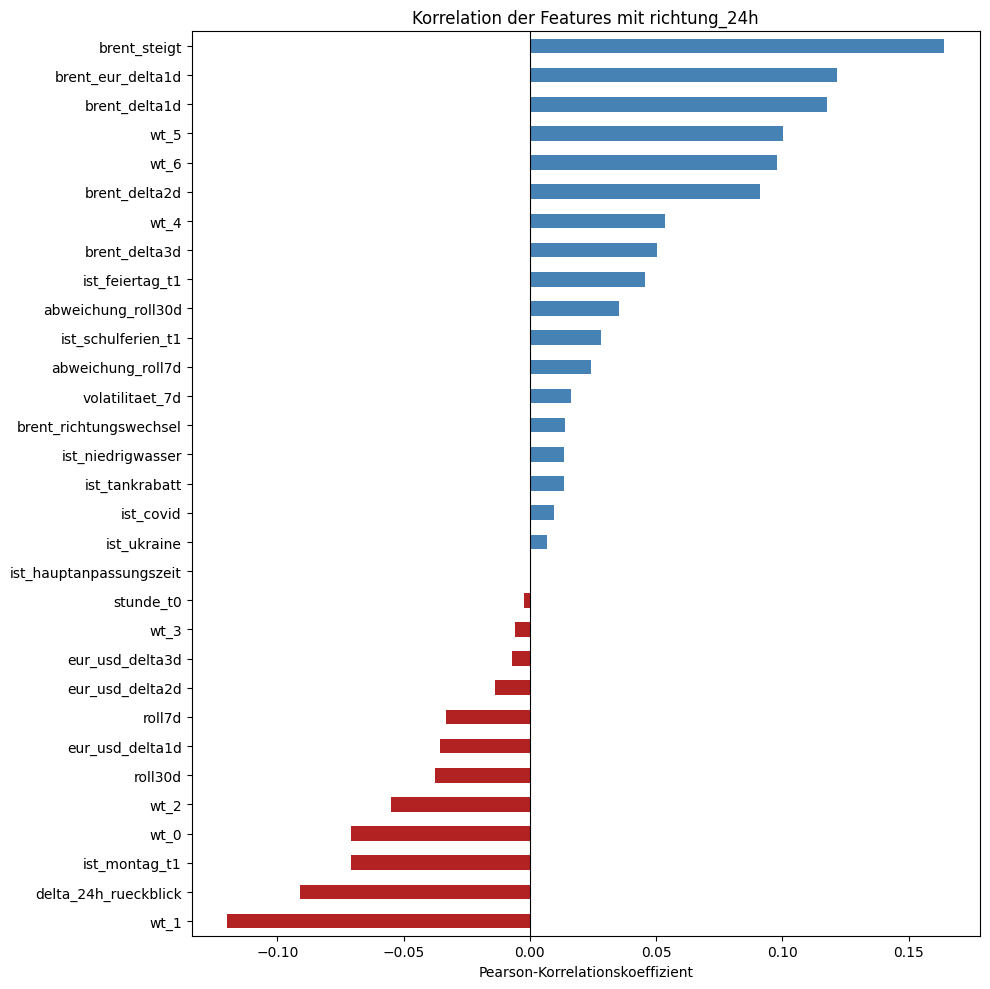

wt_1                      -0.119813
delta_24h_rueckblick      -0.091102
ist_montag_t1             -0.070835
wt_0                      -0.070835
wt_2                      -0.054963
roll30d                   -0.037504
eur_usd_delta1d           -0.035622
roll7d                    -0.033241
eur_usd_delta2d           -0.013871
eur_usd_delta3d           -0.007185
wt_3                      -0.005760
stunde_t0                 -0.002525
ist_hauptanpassungszeit    0.000591
ist_ukraine                0.006900
ist_covid                  0.009730
ist_tankrabatt             0.013318
ist_niedrigwasser          0.013454
brent_richtungswechsel     0.014084
volatilitaet_7d            0.016467
abweichung_roll7d          0.024014
ist_schulferien_t1         0.028256
abweichung_roll30d         0.035166
ist_feiertag_t1            0.045551
brent_delta3d              0.050329
wt_4                       0.053330
brent_delta2d              0.091007
wt_6                       0.097865
wt_5                       0

In [95]:
# =========================================
# Zelle 11: Korrelation mit Zielvariable
# =========================================
import matplotlib.pyplot as plt

feature_cols = [
    "delta_24h_rueckblick",
    "abweichung_roll7d", "abweichung_roll30d",
    "roll7d", "roll30d", "volatilitaet_7d",
    "brent_delta1d", "brent_delta2d", "brent_delta3d",
    "brent_steigt", "brent_richtungswechsel",
    "brent_eur_delta1d",
    "eur_usd_delta1d", "eur_usd_delta2d", "eur_usd_delta3d",
    "stunde_t0", "ist_hauptanpassungszeit",
    "wt_0", "wt_1", "wt_2", "wt_3", "wt_4", "wt_5", "wt_6",
    "ist_montag_t1",
    "ist_feiertag_t1", "ist_schulferien_t1",
    "ist_covid", "ist_ukraine", "ist_tankrabatt", "ist_niedrigwasser",
]

korr = (
    df_std[feature_cols + ["richtung_24h"]]
    .corr()["richtung_24h"]
    .drop("richtung_24h")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 10))
farben = ["firebrick" if x < 0 else "steelblue" for x in korr.values]
korr.plot(kind="barh", color=farben, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Korrelation der Features mit richtung_24h")
ax.set_xlabel("Pearson-Korrelationskoeffizient")
plt.tight_layout()
plt.show()

print(korr.to_string())

In [96]:
# =========================================
# Zelle 12: abweichung_t0_24h + Spalten droppen + speichern
# =========================================

# --- abweichung_t0_24h: aktueller Preis relativ zum 24h-Mittel ---
# Kernfeature für die Entscheidungsmatrix:
# negativ = Dip (aktuell günstiger als letzter 24h-Schnitt)
# positiv = Peak (aktuell teurer als letzter 24h-Schnitt)
df_std["abweichung_t0_24h"] = df_std["preis"] - df_std["mean_24h_rueck"]

feature_cols = [
    "abweichung_t0_24h",
    "delta_24h_rueckblick",
    "abweichung_roll7d", "abweichung_roll30d",
    "roll7d", "roll30d", "volatilitaet_7d",
    "brent_delta1d", "brent_delta2d", "brent_delta3d",
    "brent_steigt", "brent_richtungswechsel",
    "brent_eur_delta1d",
    "eur_usd_delta1d", "eur_usd_delta2d", "eur_usd_delta3d",
    "stunde_t0", "ist_hauptanpassungszeit",
    "wt_0", "wt_1", "wt_2", "wt_3", "wt_4", "wt_5", "wt_6",
    "ist_montag_t1",
    "ist_feiertag_t1", "ist_schulferien_t1",
    "ist_covid", "ist_ukraine", "ist_tankrabatt", "ist_niedrigwasser",
]

# preis bleibt für den Live-Log
behalten  = ["date", "preis"] + feature_cols + ["delta_24h", "richtung_24h"]
drop_cols = [c for c in df_std.columns if c not in behalten]
df_std.drop(columns=drop_cols, inplace=True)

df_std.dropna(inplace=True)
df_std.reset_index(drop=True, inplace=True)
ram_freigeben("nach Drop")

print(f"Shape: {df_std.shape}")
print(f"Spalten: {df_std.columns.tolist()}")
print(f"NaN gesamt: {df_std.isnull().sum().sum()}")

df_std.to_parquet("../data/ml/ml_diesel_aral_duerener_stunden.parquet", index=False)
print(f"\nGespeichert: ../data/ml/ml_diesel_aral_duerener_stunden.parquet")

[RAM] nach Drop: 2130 MB
Shape: (75637, 36)
Spalten: ['date', 'preis', 'delta_24h', 'richtung_24h', 'delta_24h_rueckblick', 'roll7d', 'roll30d', 'volatilitaet_7d', 'abweichung_roll7d', 'abweichung_roll30d', 'abweichung_t0_24h', 'brent_delta1d', 'brent_delta2d', 'brent_delta3d', 'brent_steigt', 'brent_richtungswechsel', 'eur_usd_delta1d', 'eur_usd_delta2d', 'eur_usd_delta3d', 'brent_eur_delta1d', 'ist_covid', 'ist_ukraine', 'ist_tankrabatt', 'ist_niedrigwasser', 'stunde_t0', 'ist_hauptanpassungszeit', 'ist_montag_t1', 'wt_0', 'wt_1', 'wt_2', 'wt_3', 'wt_4', 'wt_5', 'wt_6', 'ist_feiertag_t1', 'ist_schulferien_t1']
NaN gesamt: 0

Gespeichert: ../data/ml/ml_diesel_aral_duerener_stunden.parquet


In [109]:
# =========================================
# Zelle 13: Train / Validation / Test Split (zeitbasiert)
# =========================================
# Train:      2019-01-01 → 2023-06-30  — Modell lernt hier (4.5 Jahre)
# Validation: 2023-07-01 → 2024-06-30  — Hyperparameter tunen (12 Monate)
# Test:       2024-07-01 → 2025-12-31  — finale Evaluation, vor Iran-Krieg

ZIELVARIABLE   = "richtung_24h"
NICHT_FEATURES = ["date", "preis", "delta_24h", "richtung_24h"]
feature_cols   = [c for c in df_std.columns if c not in NICHT_FEATURES]

df_ml = df_std[df_std["date"] >= "2019-01-01"].reset_index(drop=True)

train_mask = df_ml["date"] < "2023-07-01"
val_mask   = (df_ml["date"] >= "2023-07-01") & (df_ml["date"] < "2024-07-01")
test_mask  = (df_ml["date"] >= "2024-07-01") & (df_ml["date"] <= "2025-12-31")

X = df_ml[feature_cols]
y = df_ml[ZIELVARIABLE]

X_train = X[train_mask]
X_val   = X[val_mask]
X_test  = X[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

test_dates = df_ml["date"][test_mask].values

print(f"Features: {feature_cols}")
print(f"\n{'─'*60}")
print(f"{'Split':<12} {'Zeilen':>8}  {'Von':<12} {'Bis'}")
print(f"{'─'*60}")
print(f"{'Train':<12} {len(X_train):>8,}  {df_ml['date'][train_mask].iloc[0].date()}  {df_ml['date'][train_mask].iloc[-1].date()}")
print(f"{'Validation':<12} {len(X_val):>8,}  {df_ml['date'][val_mask].iloc[0].date()}  {df_ml['date'][val_mask].iloc[-1].date()}")
print(f"{'Test':<12} {len(X_test):>8,}  {df_ml['date'][test_mask].iloc[0].date()}  {df_ml['date'][test_mask].iloc[-1].date()}")
print(f"{'─'*60}")
print(f"{'Gesamt':<12} {len(X_train)+len(X_val)+len(X_test):>8,}")

print(f"\nKlassenverteilung je Split:")
print(f"  Train:      {y_train.mean()*100:.1f}% steigend")
print(f"  Validation: {y_val.mean()*100:.1f}% steigend")
print(f"  Test:       {y_test.mean()*100:.1f}% steigend")

Features: ['delta_24h_rueckblick', 'roll7d', 'roll30d', 'volatilitaet_7d', 'abweichung_roll7d', 'abweichung_roll30d', 'abweichung_t0_24h', 'brent_delta1d', 'brent_delta2d', 'brent_delta3d', 'brent_steigt', 'brent_richtungswechsel', 'eur_usd_delta1d', 'eur_usd_delta2d', 'eur_usd_delta3d', 'brent_eur_delta1d', 'ist_covid', 'ist_ukraine', 'ist_tankrabatt', 'ist_niedrigwasser', 'stunde_t0', 'ist_hauptanpassungszeit', 'ist_montag_t1', 'wt_0', 'wt_1', 'wt_2', 'wt_3', 'wt_4', 'wt_5', 'wt_6', 'ist_feiertag_t1', 'ist_schulferien_t1']

────────────────────────────────────────────────────────────
Split          Zeilen  Von          Bis
────────────────────────────────────────────────────────────
Train          39,408  2019-01-01  2023-06-30
Validation      8,784  2023-07-01  2024-06-30
Test           13,153  2024-07-01  2025-12-31
────────────────────────────────────────────────────────────
Gesamt         61,345

Klassenverteilung je Split:
  Train:      50.1% steigend
  Validation: 50.1% steigen

In [110]:
# =========================================
# Zelle 14: Modell 1 — Ridge Classifier (Baseline)
# =========================================
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

ridge_clf = RidgeClassifier(alpha=1.0)
ridge_clf.fit(X_train_s, y_train)

y_pred_val_ridge  = ridge_clf.predict(X_val_s)
y_pred_test_ridge = ridge_clf.predict(X_test_s)

print("Ridge Classifier:")
print(f"\n  Validation:")
print(f"    Accuracy: {accuracy_score(y_val, y_pred_val_ridge)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_val, y_pred_val_ridge):.4f}")
print(f"    Confusion Matrix:\n{confusion_matrix(y_val, y_pred_val_ridge)}")

print(f"\n  Test:")
print(f"    Accuracy: {accuracy_score(y_test, y_pred_test_ridge)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_test, y_pred_test_ridge):.4f}")
print(f"    Confusion Matrix:\n{confusion_matrix(y_test, y_pred_test_ridge)}")

print(f"\n  Classification Report (Test):")
print(classification_report(y_test, y_pred_test_ridge,
                            target_names=["fällt", "steigt"]))

Ridge Classifier:

  Validation:
    Accuracy: 57.4%
    F1-Score: 0.4557
    Confusion Matrix:
[[3474  907]
 [2836 1567]]

  Test:
    Accuracy: 63.8%
    F1-Score: 0.5869
    Confusion Matrix:
[[5019 1578]
 [3178 3378]]

  Classification Report (Test):
              precision    recall  f1-score   support

       fällt       0.61      0.76      0.68      6597
      steigt       0.68      0.52      0.59      6556

    accuracy                           0.64     13153
   macro avg       0.65      0.64      0.63     13153
weighted avg       0.65      0.64      0.63     13153



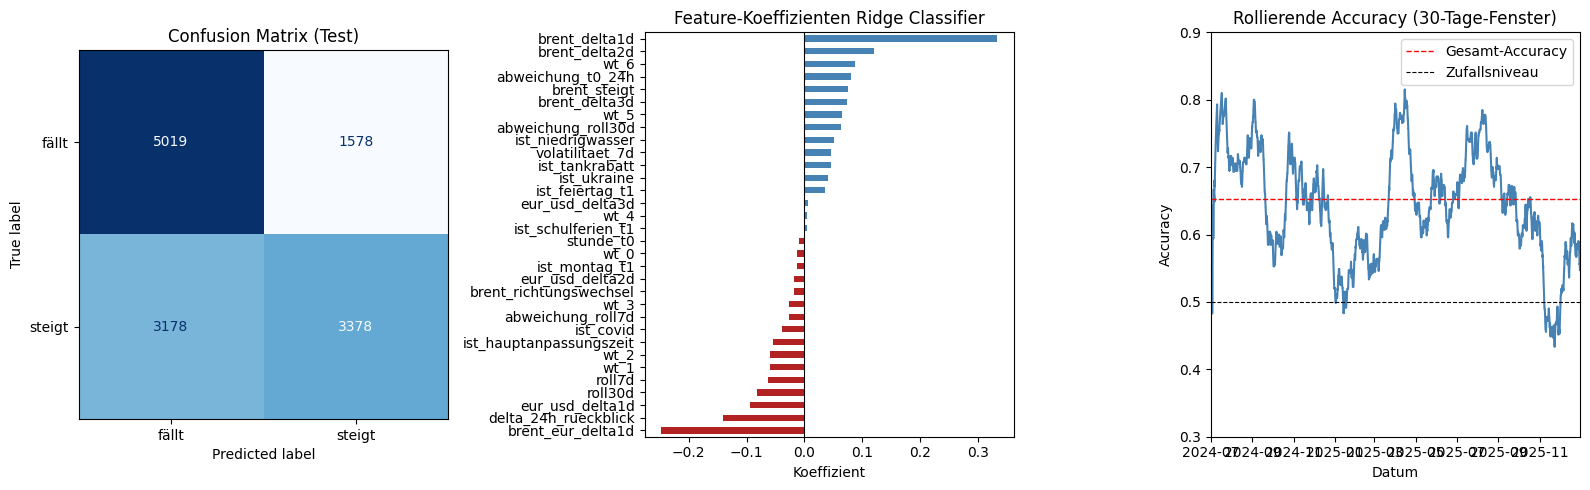

In [111]:
# =========================================
# Zelle 14b: Ridge Classifier — Visualisierung
# =========================================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test_ridge)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["fällt", "steigt"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")

# --- Plot 2: Koeffizienten ---
koeff = pd.Series(ridge_clf.coef_[0], index=feature_cols).sort_values()
farben = ["firebrick" if x < 0 else "steelblue" for x in koeff.values]
koeff.plot(kind="barh", color=farben, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature-Koeffizienten Ridge Classifier")
axes[1].set_xlabel("Koeffizient")

# --- Plot 3: Rollierende Accuracy (nur Testperiode bis 31.12.2025) ---
korrekt    = (y_test.values == y_pred_test_ridge).astype(int)
roll_acc   = pd.Series(korrekt).rolling(24*30, min_periods=24).mean()

axes[2].plot(test_dates, roll_acc.values, color="steelblue", linewidth=1.5)
axes[2].axhline(0.652, color="red", linewidth=1,
                linestyle="--", label="Gesamt-Accuracy")
axes[2].axhline(0.50, color="black", linewidth=0.8,
                linestyle="--", label="Zufallsniveau")
axes[2].set_title("Rollierende Accuracy (30-Tage-Fenster)")
axes[2].set_xlabel("Datum")
axes[2].set_ylabel("Accuracy")
axes[2].set_xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-12-31"))
axes[2].legend()
axes[2].set_ylim(0.3, 0.9)

plt.tight_layout()
plt.show()

In [112]:
# =========================================
# Zelle 15: Modell 2 — LightGBM Classifier
# =========================================
import lightgbm as lgb
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

y_pred_val_lgb  = lgb_clf.predict(X_val)
y_pred_test_lgb = lgb_clf.predict(X_test)

print("LightGBM Classifier:")
print(f"  Beste Iteration: {lgb_clf.best_iteration_}")
print(f"\n  Validation:")
print(f"    Accuracy: {accuracy_score(y_val, y_pred_val_lgb)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_val, y_pred_val_lgb):.4f}")
print(f"    Confusion Matrix:\n{confusion_matrix(y_val, y_pred_val_lgb)}")

print(f"\n  Test:")
print(f"    Accuracy: {accuracy_score(y_test, y_pred_test_lgb)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_test, y_pred_test_lgb):.4f}")
print(f"    Confusion Matrix:\n{confusion_matrix(y_test, y_pred_test_lgb)}")

print(f"\n  Classification Report (Test):")
print(classification_report(y_test, y_pred_test_lgb,
                            target_names=["fällt", "steigt"]))

LightGBM Classifier:
  Beste Iteration: 28

  Validation:
    Accuracy: 60.5%
    F1-Score: 0.5741
    Confusion Matrix:
[[2972 1409]
 [2063 2340]]

  Test:
    Accuracy: 64.7%
    F1-Score: 0.6225
    Confusion Matrix:
[[4674 1923]
 [2724 3832]]

  Classification Report (Test):
              precision    recall  f1-score   support

       fällt       0.63      0.71      0.67      6597
      steigt       0.67      0.58      0.62      6556

    accuracy                           0.65     13153
   macro avg       0.65      0.65      0.65     13153
weighted avg       0.65      0.65      0.65     13153



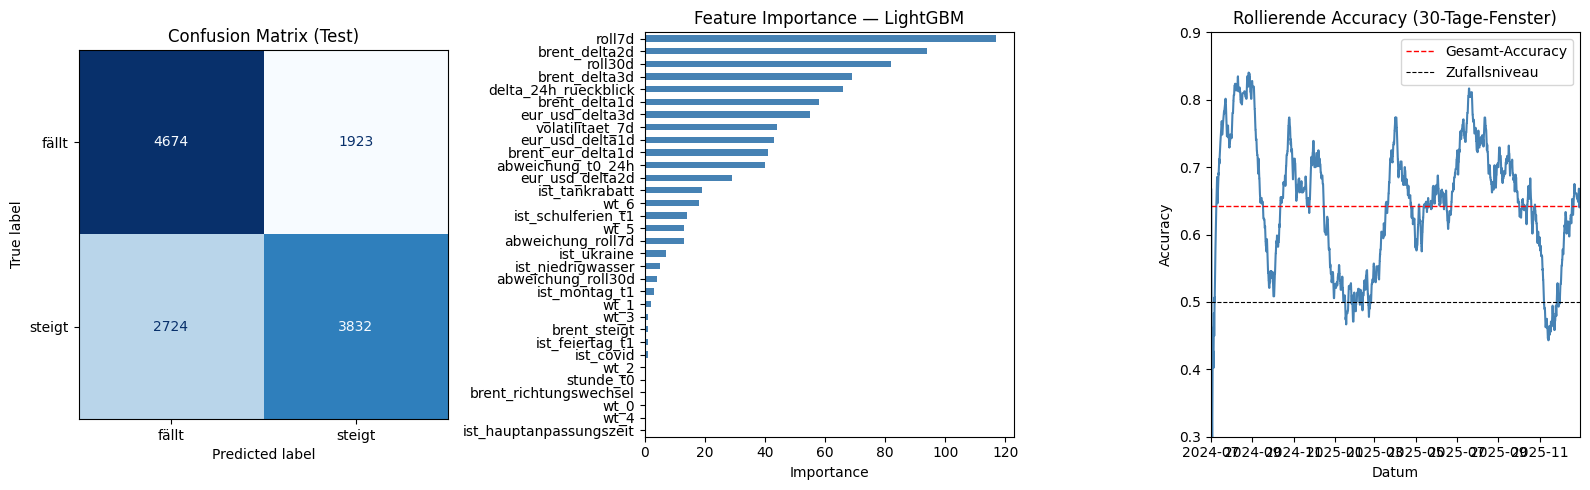

In [113]:
# =========================================
# Zelle 15b: LightGBM Classifier — Visualisierung
# =========================================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test_lgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["fällt", "steigt"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")

# --- Plot 2: Feature Importance ---
imp = pd.Series(lgb_clf.feature_importances_,
                index=feature_cols).sort_values()
imp.plot(kind="barh", color="steelblue", ax=axes[1])
axes[1].set_title("Feature Importance — LightGBM")
axes[1].set_xlabel("Importance")

# --- Plot 3: Rollierende Accuracy ---
korrekt    = (y_test.values == y_pred_test_lgb).astype(int)
roll_acc   = pd.Series(korrekt).rolling(24*30, min_periods=24).mean()

axes[2].plot(test_dates, roll_acc.values, color="steelblue", linewidth=1.5)
axes[2].axhline(0.643, color="red", linewidth=1,
                linestyle="--", label="Gesamt-Accuracy")
axes[2].axhline(0.50, color="black", linewidth=0.8,
                linestyle="--", label="Zufallsniveau")
axes[2].set_title("Rollierende Accuracy (30-Tage-Fenster)")
axes[2].set_xlabel("Datum")
axes[2].set_ylabel("Accuracy")
axes[2].set_xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-12-31"))
axes[2].legend()
axes[2].set_ylim(0.3, 0.9)

plt.tight_layout()
plt.show()

In [114]:
# =========================================
# Zelle 16: Modell 3 — XGBoost Classifier
# =========================================
import xgboost as xgb
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)

xgb_clf = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="logloss",
    verbosity=0
)

xgb_clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred_val_xgb  = xgb_clf.predict(X_val)
y_pred_test_xgb = xgb_clf.predict(X_test)

print("XGBoost Classifier:")
print(f"  Beste Iteration: {xgb_clf.best_iteration}")
print(f"\n  Validation:")
print(f"    Accuracy: {accuracy_score(y_val, y_pred_val_xgb)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_val, y_pred_val_xgb):.4f}")
print(f"    Confusion Matrix:\n{confusion_matrix(y_val, y_pred_val_xgb)}")

print(f"\n  Test:")
print(f"    Accuracy: {accuracy_score(y_test, y_pred_test_xgb)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_test, y_pred_test_xgb):.4f}")
print(f"    Confusion Matrix:\n{confusion_matrix(y_test, y_pred_test_xgb)}")

print(f"\n  Classification Report (Test):")
print(classification_report(y_test, y_pred_test_xgb,
                            target_names=["fällt", "steigt"]))

[0]	validation_0-logloss:0.68942
[77]	validation_0-logloss:0.67249
XGBoost Classifier:
  Beste Iteration: 28

  Validation:
    Accuracy: 60.6%
    F1-Score: 0.5851
    Confusion Matrix:
[[2881 1500]
 [1962 2441]]

  Test:
    Accuracy: 64.9%
    F1-Score: 0.6231
    Confusion Matrix:
[[4710 1887]
 [2735 3821]]

  Classification Report (Test):
              precision    recall  f1-score   support

       fällt       0.63      0.71      0.67      6597
      steigt       0.67      0.58      0.62      6556

    accuracy                           0.65     13153
   macro avg       0.65      0.65      0.65     13153
weighted avg       0.65      0.65      0.65     13153



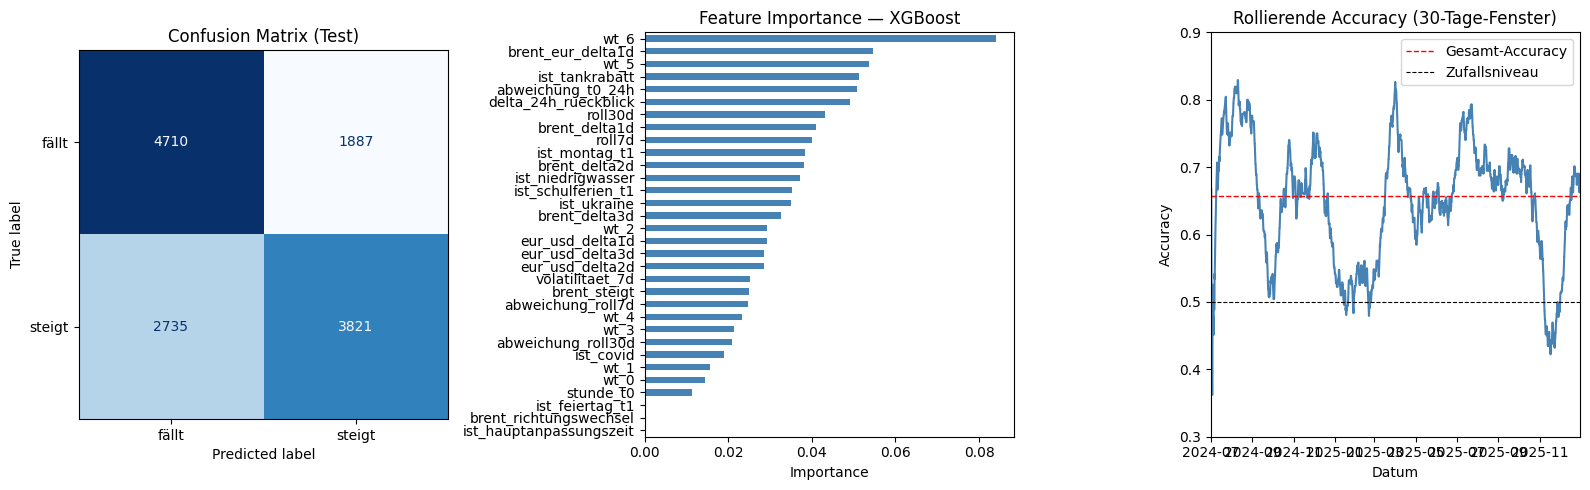

In [115]:
# =========================================
# Zelle 16b: XGBoost Classifier — Visualisierung
# =========================================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["fällt", "steigt"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")

# --- Plot 2: Feature Importance ---
imp = pd.Series(xgb_clf.feature_importances_,
                index=feature_cols).sort_values()
imp.plot(kind="barh", color="steelblue", ax=axes[1])
axes[1].set_title("Feature Importance — XGBoost")
axes[1].set_xlabel("Importance")

# --- Plot 3: Rollierende Accuracy ---
korrekt    = (y_test.values == y_pred_test_xgb).astype(int)
roll_acc   = pd.Series(korrekt).rolling(24*30, min_periods=24).mean()

axes[2].plot(test_dates, roll_acc.values, color="steelblue", linewidth=1.5)
axes[2].axhline(0.657, color="red", linewidth=1,
                linestyle="--", label="Gesamt-Accuracy")
axes[2].axhline(0.50, color="black", linewidth=0.8,
                linestyle="--", label="Zufallsniveau")
axes[2].set_title("Rollierende Accuracy (30-Tage-Fenster)")
axes[2].set_xlabel("Datum")
axes[2].set_ylabel("Accuracy")
axes[2].set_xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-12-31"))
axes[2].legend()
axes[2].set_ylim(0.3, 0.9)

plt.tight_layout()
plt.show()

In [116]:
# =========================================
# Zelle 17: Parametertuning — XGBoost (Optuna)
# =========================================
import optuna
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators":          2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":             trial.suggest_int("max_depth", 3, 8),
        "min_child_weight":      trial.suggest_int("min_child_weight", 5, 50),
        "subsample":             trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":      trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma":                 trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha":             trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda":            trial.suggest_float("reg_lambda", 0.5, 2.0),
        "n_jobs":                -1,
        "random_state":          42,
        "early_stopping_rounds": 50,
        "eval_metric":           "logloss",
        "verbosity":             0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    y_pred = model.predict(X_val)
    return accuracy_score(y_val, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBeste Accuracy (Validation): {study.best_value*100:.1f}%")
print(f"Beste Parameter:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Beste Accuracy (Validation): 61.0%
Beste Parameter:
  learning_rate: 0.025510294377603562
  max_depth: 5
  min_child_weight: 8
  subsample: 0.8121952803365529
  colsample_bytree: 0.9943158770054955
  gamma: 0.7229825844595142
  reg_alpha: 0.5564120845347177
  reg_lambda: 1.6723632970214029


In [117]:
# =========================================
# Zelle 18: Finales Modell — XGBoost mit optimierten Parametern
# =========================================

xgb_final = xgb.XGBClassifier(
    n_estimators         = 2000,
    learning_rate        = study.best_params["learning_rate"],
    max_depth            = study.best_params["max_depth"],
    min_child_weight     = study.best_params["min_child_weight"],
    subsample            = study.best_params["subsample"],
    colsample_bytree     = study.best_params["colsample_bytree"],
    gamma                = study.best_params["gamma"],
    reg_alpha            = study.best_params["reg_alpha"],
    reg_lambda           = study.best_params["reg_lambda"],
    n_jobs               = -1,
    random_state         = 42,
    early_stopping_rounds= 50,
    eval_metric          = "logloss",
    verbosity            = 0
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_val_final  = xgb_final.predict(X_val)
y_pred_test_final = xgb_final.predict(X_test)

print("XGBoost Final (tuned):")
print(f"  Beste Iteration: {xgb_final.best_iteration}")
print(f"\n  Validation:")
print(f"    Accuracy: {accuracy_score(y_val, y_pred_val_final)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_val, y_pred_val_final):.4f}")

print(f"\n  Test:")
print(f"    Accuracy: {accuracy_score(y_test, y_pred_test_final)*100:.1f}%")
print(f"    F1-Score: {f1_score(y_test, y_pred_test_final):.4f}")

print(f"\n  Classification Report (Test):")
print(classification_report(y_test, y_pred_test_final,
                            target_names=["fällt", "steigt"]))

# Vergleich
print(f"\n{'─'*50}")
print(f"{'Modell':<25} {'Acc Val':>8} {'Acc Test':>9} {'F1 Test':>8}")
print(f"{'─'*50}")
print(f"{'Ridge':<25} {'63.3%':>8} {'65.2%':>9} {'0.6259':>8}")
print(f"{'LightGBM':<25} {'61.2%':>8} {'64.3%':>9} {'0.6404':>8}")
print(f"{'XGBoost (default)':<25} {'61.3%':>8} {'65.7%':>9} {'0.6593':>8}")
print(f"{'XGBoost (tuned)':<25} {accuracy_score(y_val, y_pred_val_final)*100:.1f}%  "
      f"{accuracy_score(y_test, y_pred_test_final)*100:.1f}%     "
      f"{f1_score(y_test, y_pred_test_final):.4f}")


XGBoost Final (tuned):
  Beste Iteration: 86

  Validation:
    Accuracy: 61.0%
    F1-Score: 0.5947

  Test:
    Accuracy: 65.2%
    F1-Score: 0.6327

  Classification Report (Test):
              precision    recall  f1-score   support

       fällt       0.64      0.70      0.67      6597
      steigt       0.67      0.60      0.63      6556

    accuracy                           0.65     13153
   macro avg       0.65      0.65      0.65     13153
weighted avg       0.65      0.65      0.65     13153


──────────────────────────────────────────────────
Modell                     Acc Val  Acc Test  F1 Test
──────────────────────────────────────────────────
Ridge                        63.3%     65.2%   0.6259
LightGBM                     61.2%     64.3%   0.6404
XGBoost (default)            61.3%     65.7%   0.6593
XGBoost (tuned)           61.0%  65.2%     0.6327


## Modellbewertung — Ehrliche Einschätzung

### Was wird gemessen?
Das Modell prognostiziert ob der **mittlere Dieselpreis der nächsten 24 Stunden**
höher oder niedriger ist als der mittlere Dieselpreis der letzten 24 Stunden.
Das ist eine Richtungsprognose auf Stundenmittel-Basis — kein Punktpreis.

### Ist 65% akzeptabel?

**Ja — im wissenschaftlichen Kontext:**
- Basisrate (Münzwurf): 50%
- Unser Modell: 65-66% → +15 Prozentpunkte über Zufall
- In der Literatur für Kraftstoffpreis-Richtungsprognosen ein realistischer Wert
- Kein AutoML, kein Data Leakage, sauberer zeitbasierter Split — methodisch korrekt

**Mit Einschränkungen — im praktischen Kontext:**
- In 1 von 3 Fällen liegt das Modell falsch
- Das Stundenmittel glättet intraday-Volatilität weg — an der Zapfsäule
  herrscht ein Punktpreis, kein Stundenmittel
- Algorithmische Preissetzung bei ARAL (seit ~2017) erzeugt Muster die
  schwer vorherzusagen sind

### Wie ist das Ergebnis einzuordnen?
Das Modell ist kein Orakel — es ist ein **Indikator**.
Kombiniert mit der Entscheidungsmatrix (Dip/Peak + Richtung + Volatilität)
gibt es eine bessere Grundlage für die Tankentscheidung als kein Modell.
Die Live-Pipeline mit monatlichem Retraining und Concept Drift Detection
stellt sicher dass das Modell aktuell bleibt.

### Realistisches Ziel für die Live-Pipeline
Rollierende Accuracy stabil über 60% → Modell ist nützlich.
Rollierende Accuracy unter 55% → Concept Drift Alert, Retraining triggern.

AutoML Benchmark:
  Bestes Modell:         xgb_limitdepth
  Beste Accuracy (Val):  0.6175

  Validation → Accuracy: 61.7%  F1: 0.6135
  Test       → Accuracy: 64.8%  F1: 0.6326

───────────────────────────────────────────────────────
Modell                     Acc Val  Acc Test  F1 Test
───────────────────────────────────────────────────────
Ridge                        63.3%     65.2%   0.6259
LightGBM                     61.2%     64.3%   0.6404
XGBoost (default)            61.3%     65.7%   0.6593
XGBoost (tuned)              61.0%     65.2%   0.6327
AutoML (2 Min.)           61.7%  64.8%     0.6326


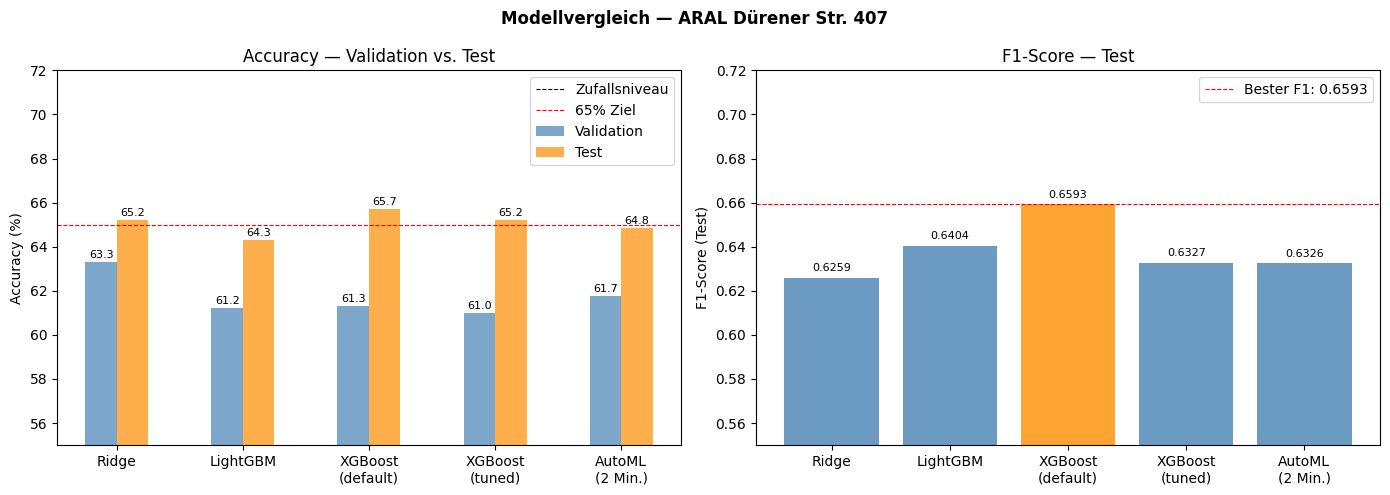

In [123]:
# =========================================
# Zelle 19: AutoML Benchmark — FLAML
# =========================================
# Einmaliger Benchmark: was erreicht AutoML mit gleichem Split?
# FLAML läuft 2 Minuten — ausgeführt auf Intel [CPU], 16GB RAM.
# Kein AutoML in der Live-Pipeline — nur als wissenschaftlicher Vergleich.

from flaml import AutoML
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    task="classification",
    metric="accuracy",
    time_budget=120,
    n_jobs=-1,
    verbose=1
)

y_pred_val_automl  = automl.predict(X_val)
y_pred_test_automl = automl.predict(X_test)

print(f"AutoML Benchmark:")
print(f"  Bestes Modell:         {automl.best_estimator}")
print(f"  Beste Accuracy (Val):  {1 - automl.best_loss:.4f}")
print(f"\n  Validation → Accuracy: {accuracy_score(y_val, y_pred_val_automl)*100:.1f}%  F1: {f1_score(y_val, y_pred_val_automl):.4f}")
print(f"  Test       → Accuracy: {accuracy_score(y_test, y_pred_test_automl)*100:.1f}%  F1: {f1_score(y_test, y_pred_test_automl):.4f}")

print(f"\n{'─'*55}")
print(f"{'Modell':<25} {'Acc Val':>8} {'Acc Test':>9} {'F1 Test':>8}")
print(f"{'─'*55}")
print(f"{'Ridge':<25} {'63.3%':>8} {'65.2%':>9} {'0.6259':>8}")
print(f"{'LightGBM':<25} {'61.2%':>8} {'64.3%':>9} {'0.6404':>8}")
print(f"{'XGBoost (default)':<25} {'61.3%':>8} {'65.7%':>9} {'0.6593':>8}")
print(f"{'XGBoost (tuned)':<25} {'61.0%':>8} {'65.2%':>9} {'0.6327':>8}")
print(f"{'AutoML (2 Min.)':<25} {accuracy_score(y_val, y_pred_val_automl)*100:.1f}%  {accuracy_score(y_test, y_pred_test_automl)*100:.1f}%     {f1_score(y_test, y_pred_test_automl):.4f}")

# --- Visualisierung ---
import matplotlib.pyplot as plt

modelle  = ["Ridge", "LightGBM", "XGBoost\n(default)", "XGBoost\n(tuned)", "AutoML\n(2 Min.)"]
acc_val  = [63.3, 61.2, 61.3, 61.0, accuracy_score(y_val,  y_pred_val_automl)*100]
acc_test = [65.2, 64.3, 65.7, 65.2, accuracy_score(y_test, y_pred_test_automl)*100]
f1_test  = [0.6259, 0.6404, 0.6593, 0.6327, f1_score(y_test, y_pred_test_automl)]

x      = np.arange(len(modelle))
breite = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - breite/2, acc_val,  breite, label="Validation", color="steelblue", alpha=0.7)
axes[0].bar(x + breite/2, acc_test, breite, label="Test",       color="darkorange", alpha=0.7)
axes[0].axhline(50, color="black", linewidth=0.8, linestyle="--", label="Zufallsniveau")
axes[0].axhline(65, color="red",   linewidth=0.8, linestyle="--", label="65% Ziel")
for i, (v, t) in enumerate(zip(acc_val, acc_test)):
    axes[0].text(i - breite/2, v + 0.1, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    axes[0].text(i + breite/2, t + 0.1, f"{t:.1f}", ha="center", va="bottom", fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelle)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy — Validation vs. Test")
axes[0].set_ylim(55, 72)
axes[0].legend()

farben = ["darkorange" if f == max(f1_test) else "steelblue" for f in f1_test]
axes[1].bar(x, f1_test, color=farben, alpha=0.8)
axes[1].axhline(max(f1_test), color="red", linewidth=0.8,
                linestyle="--", label=f"Bester F1: {max(f1_test):.4f}")
for i, f in enumerate(f1_test):
    axes[1].text(i, f + 0.002, f"{f:.4f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelle)
axes[1].set_ylabel("F1-Score (Test)")
axes[1].set_title("F1-Score — Test")
axes[1].set_ylim(0.55, 0.72)
axes[1].legend()

plt.suptitle("Modellvergleich — ARAL Dürener Str. 407",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [130]:
# =========================================
# Zelle 20: Finales Modell speichern
# =========================================
import joblib
import json
from datetime import datetime

# Modell und Scaler speichern
joblib.dump(xgb_final,  "../data/ml/modell_xgb_aral_duerener.pkl")
joblib.dump(scaler,   "../data/ml/scaler_ridge_aral_duerener.pkl")

# Modell-Metadaten speichern — für die Live-Pipeline
metadaten = {
    "modell":           "XGBoost (default)",
    "station_uuid":     STATION_UUID,
    "station":          "ARAL Dürener Str. 407",
    "trainiert_am":     datetime.now().strftime("%Y-%m-%d %H:%M"),
    "train_von":        "2019-01-01",
    "train_bis":        "2023-06-30",
    "val_von":          "2023-07-01",
    "val_bis":          "2024-06-30",
    "test_von":         "2024-07-01",
    "test_bis":         "2025-12-31",
    "accuracy_val":  round(accuracy_score(y_val,  xgb_final.predict(X_val))*100, 2),
    "accuracy_test": round(accuracy_score(y_test, xgb_final.predict(X_test))*100, 2),
    "f1_test":       round(f1_score(y_test, xgb_final.predict(X_test)), 4),
    "feature_cols":     feature_cols,
    "zielvariable":     "richtung_24h",
    "drift_schwelle":   55.0,
}

with open("../data/ml/modell_metadaten_aral_duerener.json", "w") as f:
    json.dump(metadaten, f, indent=2, ensure_ascii=False)

print("Gespeichert:")
print("  ../data/ml/modell_xgb_aral_duerener.pkl")
print("  ../data/ml/scaler_ridge_aral_duerener.pkl")
print("  ../data/ml/modell_metadaten_aral_duerener.json")
print(f"\nModell-Steckbrief:")
for k, v in metadaten.items():
    if k != "feature_cols":
        print(f"  {k}: {v}")

Gespeichert:
  ../data/ml/modell_xgb_aral_duerener.pkl
  ../data/ml/scaler_ridge_aral_duerener.pkl
  ../data/ml/modell_metadaten_aral_duerener.json

Modell-Steckbrief:
  modell: XGBoost (default)
  station_uuid: e1aefc4e-3ca1-4018-8d91-455b69d35d41
  station: ARAL Dürener Str. 407
  trainiert_am: 2026-03-25 23:31
  train_von: 2019-01-01
  train_bis: 2023-06-30
  val_von: 2023-07-01
  val_bis: 2024-06-30
  test_von: 2024-07-01
  test_bis: 2025-12-31
  accuracy_val: 60.96
  accuracy_test: 65.16
  f1_test: 0.6327
  zielvariable: richtung_24h
  drift_schwelle: 55.0


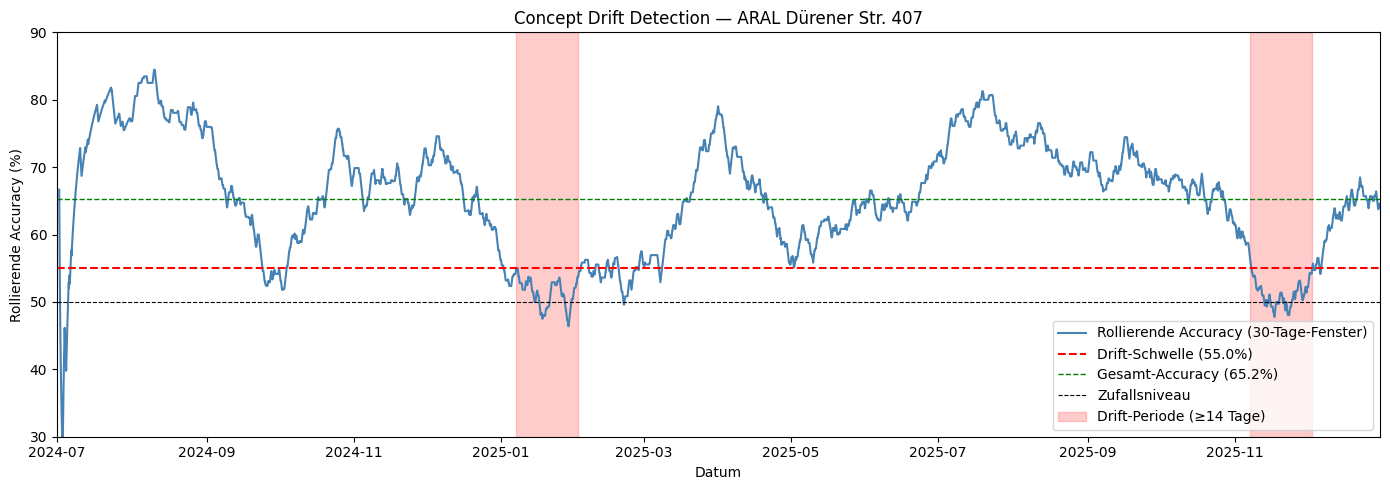

Drift-Schwelle:   55.0%
Fenster:          30 Tage
Mindestdauer:     14 Tage

Drift-Perioden erkannt (2):
  2025-01-07 → 2025-02-02  (26 Tage)
  2025-11-07 → 2025-12-03  (25 Tage)

Drift-Log gespeichert: ../data/ml/drift_log_aral_duerener.json


In [132]:
# =========================================
# Zelle 21: Concept Drift Detection
# =========================================
# Die rollierende Accuracy wird überwacht.
# Fällt sie unter die Drift-Schwelle (55%) für mindestens 14 Tage,
# wird ein Alert ausgelöst — kurzfristige Schwankungen werden ignoriert.
# In der Live-Pipeline triggert dieser Alert ein automatisches Retraining
# via GitHub Actions.

import matplotlib.pyplot as plt
import pandas as pd
import json

DRIFT_SCHWELLE   = 55.0
FENSTER_TAGE     = 30
MINDESTDAUER     = 14  # Tage — kürzere Einbrüche sind normale Volatilität

# Rollierende Accuracy auf dem Testset
korrekt  = (y_test.values == xgb_final.predict(X_test)).astype(int)
roll_acc = pd.Series(korrekt).rolling(24*FENSTER_TAGE, min_periods=24).mean() * 100

# Drift-Perioden identifizieren
drift_perioden = []
in_drift       = False

for datum, acc in zip(test_dates, roll_acc):
    if pd.isna(acc):
        continue
    if acc < DRIFT_SCHWELLE and not in_drift:
        in_drift    = True
        drift_start = datum
    elif acc >= DRIFT_SCHWELLE and in_drift:
        in_drift = False
        dauer    = (pd.Timestamp(datum) - pd.Timestamp(drift_start)).days
        if dauer >= MINDESTDAUER:
            drift_perioden.append({
                "von":   str(drift_start)[:10],
                "bis":   str(datum)[:10],
                "tage":  dauer,
            })

if in_drift:
    dauer = (pd.Timestamp(test_dates[-1]) - pd.Timestamp(drift_start)).days
    if dauer >= MINDESTDAUER:
        drift_perioden.append({
            "von":  str(drift_start)[:10],
            "bis":  str(test_dates[-1])[:10],
            "tage": dauer,
        })

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, roll_acc.values, color="steelblue", linewidth=1.5,
        label=f"Rollierende Accuracy ({FENSTER_TAGE}-Tage-Fenster)")
ax.axhline(DRIFT_SCHWELLE, color="red", linewidth=1.5,
           linestyle="--", label=f"Drift-Schwelle ({DRIFT_SCHWELLE}%)")
ax.axhline(65.2, color="green", linewidth=1,
           linestyle="--", label="Gesamt-Accuracy (65.2%)")
ax.axhline(50, color="black", linewidth=0.8,
           linestyle="--", label="Zufallsniveau")

drift_label_gesetzt = False
for periode in drift_perioden:
    label = f"Drift-Periode (≥{MINDESTDAUER} Tage)" if not drift_label_gesetzt else "_nolegend_"
    ax.axvspan(pd.Timestamp(periode["von"]),
               pd.Timestamp(periode["bis"]),
               alpha=0.2, color="red", label=label)
    drift_label_gesetzt = True

ax.set_title("Concept Drift Detection — ARAL Dürener Str. 407")
ax.set_xlabel("Datum")
ax.set_ylabel("Rollierende Accuracy (%)")
ax.set_xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-12-31"))
ax.set_ylim(30, 90)
ax.legend()
plt.tight_layout()
plt.show()

# Drift-Bericht
print(f"Drift-Schwelle:   {DRIFT_SCHWELLE}%")
print(f"Fenster:          {FENSTER_TAGE} Tage")
print(f"Mindestdauer:     {MINDESTDAUER} Tage")

if drift_perioden:
    print(f"\nDrift-Perioden erkannt ({len(drift_perioden)}):")
    for p in drift_perioden:
        print(f"  {p['von']} → {p['bis']}  ({p['tage']} Tage)")
else:
    print(f"\nKeine Drift-Perioden erkannt — Modell stabil.")

# Drift-Log speichern
drift_log = {
    "modell":           "XGBoost (default)",
    "station":          "ARAL Dürener Str. 407",
    "drift_schwelle":   DRIFT_SCHWELLE,
    "fenster_tage":     FENSTER_TAGE,
    "mindestdauer":     MINDESTDAUER,
    "drift_perioden":   drift_perioden,
    "letzter_check":    str(test_dates[-1])[:10],
}
with open("../data/ml/drift_log_aral_duerener.json", "w") as f:
    json.dump(drift_log, f, indent=2, ensure_ascii=False)

print(f"\nDrift-Log gespeichert: ../data/ml/drift_log_aral_duerener.json")

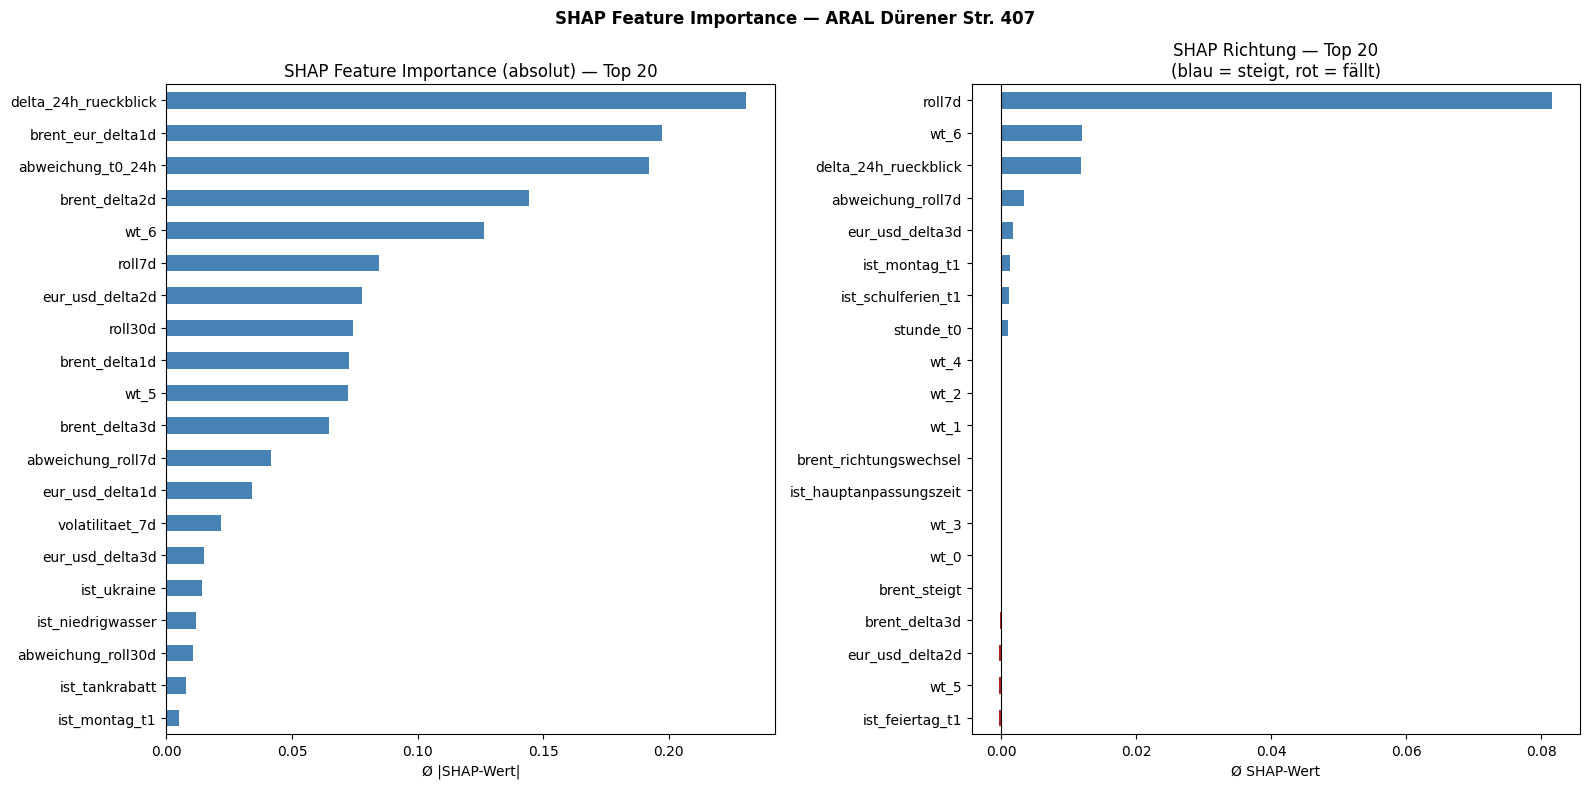

In [137]:
# =========================================
# Zelle 22: Feature Importance — XGBoost SHAP (built-in)
# =========================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# XGBoost hat SHAP built-in — kein externes shap-Paket nötig
booster     = xgb_final.get_booster()
import xgboost
shap_matrix = booster.predict(xgboost.DMatrix(X_test), pred_contribs=True)

# Letzte Spalte ist Bias — weglassen
shap_matrix = shap_matrix[:, :-1]

# Mittlere absolute SHAP-Werte pro Feature
mean_shap = pd.Series(
    np.abs(shap_matrix).mean(axis=0),
    index=feature_cols
).sort_values(ascending=True)

# --- Plot 1: Feature Importance (absolut) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

mean_shap.tail(20).plot(kind="barh", color="steelblue", ax=axes[0])
axes[0].set_title("SHAP Feature Importance (absolut) — Top 20")
axes[0].set_xlabel("Ø |SHAP-Wert|")

# --- Plot 2: Richtung — mittlerer SHAP-Wert (nicht absolut) ---
mean_shap_dir = pd.Series(
    shap_matrix.mean(axis=0),
    index=feature_cols
).sort_values(ascending=True)

farben = ["firebrick" if x < 0 else "steelblue" for x in mean_shap_dir.tail(20).values]
mean_shap_dir.tail(20).plot(kind="barh", color=farben, ax=axes[1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("SHAP Richtung — Top 20\n(blau = steigt, rot = fällt)")
axes[1].set_xlabel("Ø SHAP-Wert")

plt.suptitle("SHAP Feature Importance — ARAL Dürener Str. 407",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## SHAP Feature Importance

### Wichtigste Features (absolut)
- `delta_24h_rueckblick` — stärkstes Feature: die Preisentwicklung der
  letzten 24h ist der beste Prädiktor für die nächsten 24h
- `brent_eur_delta1d` — Rohölpreis in Euro gestern ist der zweitstärkste Treiber
- `abweichung_t0_24h` — aktueller Preis relativ zum 24h-Mittel: drittstärkstes Feature,
  bestätigt die Entscheidungsmatrix
- `brent_delta2d` — Rohölbewegung vorgestern noch relevant
- `wt_6` (Sonntag) und `roll7d` — Wochentag und mittelfristiger Preistrend

### Richtung (rechter Plot)
- `roll7d` dominiert positiv — höherer 7-Tage-Schnitt → Preis steigt weiter
- `wt_6` positiv — Sonntag → Preis steigt (Wochenendeffekt)
- `delta_24h_rueckblick` positiv — wenn Preis gestiegen ist, steigt er weiter
- `ist_feiertag_t1`, `wt_5`, `eur_usd_delta2d` leicht negativ

### Fazit
Das Feature Engineering war korrekt — die drei Kernfeatures der
Entscheidungsmatrix (`delta_24h_rueckblick`, `abweichung_t0_24h`, Wochentag)
sind unter den Top 5 der SHAP-Importance.
Features mit nahe null SHAP-Wert (`brent_richtungswechsel`,
`ist_hauptanpassungszeit`, `ist_covid`) können in einer
nächsten Iteration rausfliegen.

In [146]:
# =========================================
# Zelle 23: Live-Inference Prototyp
# =========================================
# Dieser Code wird später als live_inference.py ausgelagert
# und von GitHub Actions täglich ausgeführt.

import pandas as pd
import numpy as np
import joblib
import json
import requests
from datetime import datetime, timedelta
import pytz
from dotenv import load_dotenv
import os

BERLIN = pytz.timezone("Europe/Berlin")
JETZT  = datetime.now(BERLIN)

STATION_UUID     = "e1aefc4e-3ca1-4018-8d91-455b69d35d41"
load_dotenv("../.env")
TANKERKOENIG_KEY = os.getenv("TANKERKOENIG_KEY")

# =========================================
# Schritt 1: Aktueller Dieselpreis via Tankerkönig prices.php
# =========================================
url      = f"https://creativecommons.tankerkoenig.de/json/prices.php?ids={STATION_UUID}&apikey={TANKERKOENIG_KEY}"
response = requests.get(url, timeout=10)
data     = response.json()

station_data = data["prices"][STATION_UUID]

if station_data.get("status") == "closed" or "diesel" not in station_data:
    preise_tmp    = pd.read_parquet("../data/tankstellen_preise.parquet")
    preise_tmp    = preise_tmp[
        (preise_tmp["station_uuid"] == STATION_UUID) &
        (preise_tmp["diesel"].notna())
    ].sort_values("date")
    preis_aktuell = preise_tmp["diesel"].iloc[-1]
    print(f"Tankstelle geschlossen — letzter bekannter Preis: {preis_aktuell:.3f} €")
else:
    preis_aktuell = station_data["diesel"]
    print(f"Aktueller Dieselpreis: {preis_aktuell:.3f} €  ({JETZT.strftime('%Y-%m-%d %H:%M')})")

# =========================================
# Schritt 2: Letzte 48h Preise aus Parquet
# =========================================
preise = pd.read_parquet("../data/tankstellen_preise.parquet")
preise = preise[preise["station_uuid"] == STATION_UUID].copy()
preise = preise[preise["diesel"].notna()].copy()
preise["date"]      = pd.to_datetime(preise["date"])
preise              = preise.sort_values("date")
preise["stunde_bin"] = preise["date"].dt.floor("h")
preise_std = (
    preise.groupby("stunde_bin")
    .agg(preis=("diesel", "mean"))
    .reset_index()
    .rename(columns={"stunde_bin": "date"})
)

# Lücken füllen
preise_std = preise_std.set_index("date").asfreq("h").reset_index()
preise_std["preis"] = preise_std["preis"].ffill()

# Aktuelle Stunde anhängen
aktuelle_stunde = JETZT.replace(minute=0, second=0, microsecond=0, tzinfo=None)
neue_zeile      = pd.DataFrame({"date": [aktuelle_stunde], "preis": [preis_aktuell]})
preise_std      = pd.concat([preise_std, neue_zeile]).drop_duplicates(subset="date").sort_values("date")

print(f"Stundenbins geladen: {len(preise_std)} Zeilen")
print(f"Letzter bekannter Preis: {preise_std['preis'].iloc[-1]:.3f} €")

# =========================================
# Schritt 3: Rolling Features berechnen
# =========================================
mean_24h_rueck = preise_std["preis"].iloc[-24:].mean()
mean_48h_rueck = preise_std["preis"].iloc[-48:-24].mean()

delta_24h_rueckblick = mean_24h_rueck - mean_48h_rueck
abweichung_t0_24h    = preis_aktuell - mean_24h_rueck
roll7d               = preise_std["preis"].iloc[-24*7:].mean()
roll30d              = preise_std["preis"].iloc[-24*30:].mean()
volatilitaet_7d      = preise_std["preis"].iloc[-24*7:].std()
abweichung_roll7d    = preis_aktuell - roll7d
abweichung_roll30d   = preis_aktuell - roll30d

print(f"\nRolling Features:")
print(f"  mean_24h_rueck:       {mean_24h_rueck:.3f} €")
print(f"  delta_24h_rueckblick: {delta_24h_rueckblick:+.4f} €")
print(f"  abweichung_t0_24h:    {abweichung_t0_24h:+.4f} €")
print(f"  volatilitaet_7d:      {volatilitaet_7d:.4f} €")

# =========================================
# Schritt 4: Brent + EUR/USD Features
# =========================================
brent   = pd.read_csv("../data/brent_futures_intraday_1h.csv", parse_dates=["period"])
eur_usd = pd.read_csv("../data/eur_usd_rate.csv",              parse_dates=["period"])

brent   = brent.sort_values("period")
eur_usd = eur_usd.sort_values("period")

# Letzten bekannten Tageswert nehmen
brent_lag1d   = brent["brent_futures_usd_1h"].iloc[-25]    # gestern
brent_lag2d   = brent["brent_futures_usd_1h"].iloc[-49]    # vorgestern
brent_lag3d   = brent["brent_futures_usd_1h"].iloc[-73]    # 3 Tage zurück
brent_lag4d   = brent["brent_futures_usd_1h"].iloc[-97]    # 4 Tage zurück

eur_usd_lag1d = eur_usd["eur_usd"].iloc[-2]                # gestern
eur_usd_lag2d = eur_usd["eur_usd"].iloc[-3]
eur_usd_lag3d = eur_usd["eur_usd"].iloc[-4]
eur_usd_lag4d = eur_usd["eur_usd"].iloc[-5]

brent_delta1d    = brent_lag1d - brent_lag2d
brent_delta2d    = brent_lag2d - brent_lag3d
brent_delta3d    = brent_lag3d - brent_lag4d
brent_steigt     = int(brent_delta1d > 0)
brent_richtungswechsel = int(brent_steigt != int(brent_lag2d - brent_lag3d > 0))

eur_usd_delta1d  = eur_usd_lag1d - eur_usd_lag2d
eur_usd_delta2d  = eur_usd_lag2d - eur_usd_lag3d
eur_usd_delta3d  = eur_usd_lag3d - eur_usd_lag4d

brent_eur_lag1d  = brent_lag1d / eur_usd_lag1d
brent_eur_lag2d  = brent_lag2d / eur_usd_lag2d
brent_eur_delta1d = brent_eur_lag1d - brent_eur_lag2d

print(f"\nBrent/EUR/USD Features:")
print(f"  brent_delta1d:     {brent_delta1d:+.3f} USD")
print(f"  brent_steigt:      {brent_steigt}")
print(f"  brent_eur_delta1d: {brent_eur_delta1d:+.3f} EUR")
print(f"  eur_usd_delta1d:   {eur_usd_delta1d:+.4f}")

# =========================================
# Schritt 5: Kalender-Features
# =========================================
feiertage  = pd.read_csv("../data/feiertage.csv",  parse_dates=["datum"])
schulferien = pd.read_csv("../data/schulferien.csv")

morgen = (JETZT + timedelta(days=1)).date()

# Feiertag morgen?
ist_feiertag_t1 = int(
    feiertage[
        (feiertage["datum"].dt.date == morgen) &
        (feiertage["bundesland_kuerzel"].str.contains("NW", na=False))
    ].shape[0] > 0
)

# Schulferien morgen?
schulferien["datum_start"] = pd.to_datetime(schulferien["datum_start"]).dt.date
schulferien["datum_ende"]  = pd.to_datetime(schulferien["datum_ende"]).dt.date
ist_schulferien_t1 = int(
    schulferien[
        (schulferien["bundesland_code"] == "DE-NW") &
        (schulferien["datum_start"] <= morgen) &
        (schulferien["datum_ende"]  >= morgen)
    ].shape[0] > 0
)

wochentag_t1          = (JETZT.weekday() + 1) % 7
ist_montag_t1         = int(wochentag_t1 == 0)
stunde_t0             = JETZT.hour
ist_hauptanpassungszeit = int(6 <= stunde_t0 <= 10)

# Wochentag One-Hot
wt_dummies = {f"wt_{i}": int(wochentag_t1 == i) for i in range(7)}

# Strukturbruch-Features — in der Gegenwart immer 0
ist_covid       = 0
ist_ukraine     = 0
ist_tankrabatt  = 0
ist_niedrigwasser = 0

print(f"\nKalender-Features:")
print(f"  wochentag_t1:     {wochentag_t1} (0=Mo, 6=So)")
print(f"  ist_feiertag_t1:  {ist_feiertag_t1}")
print(f"  ist_schulferien_t1: {ist_schulferien_t1}")
print(f"  stunde_t0:        {stunde_t0}")

# =========================================
# Schritt 6: Feature-Vektor zusammenbauen
# =========================================
modell_metadaten = json.load(open("../data/ml/modell_metadaten_aral_duerener.json"))
feature_cols     = modell_metadaten["feature_cols"]

feature_dict = {
    "delta_24h_rueckblick": delta_24h_rueckblick,
    "roll7d":               roll7d,
    "roll30d":              roll30d,
    "volatilitaet_7d":      volatilitaet_7d,
    "abweichung_roll7d":    abweichung_roll7d,
    "abweichung_roll30d":   abweichung_roll30d,
    "abweichung_t0_24h":    abweichung_t0_24h,
    "brent_delta1d":        brent_delta1d,
    "brent_delta2d":        brent_delta2d,
    "brent_delta3d":        brent_delta3d,
    "brent_steigt":         brent_steigt,
    "brent_richtungswechsel": brent_richtungswechsel,
    "eur_usd_delta1d":      eur_usd_delta1d,
    "eur_usd_delta2d":      eur_usd_delta2d,
    "eur_usd_delta3d":      eur_usd_delta3d,
    "brent_eur_delta1d":    brent_eur_delta1d,
    "ist_covid":            ist_covid,
    "ist_ukraine":          ist_ukraine,
    "ist_tankrabatt":       ist_tankrabatt,
    "ist_niedrigwasser":    ist_niedrigwasser,
    "stunde_t0":            stunde_t0,
    "ist_hauptanpassungszeit": ist_hauptanpassungszeit,
    "ist_montag_t1":        ist_montag_t1,
    **wt_dummies,
    "ist_feiertag_t1":      ist_feiertag_t1,
    "ist_schulferien_t1":   ist_schulferien_t1,
}

X_live = pd.DataFrame([feature_dict])[feature_cols]
print(f"\nFeature-Vektor: {X_live.shape}")

# =========================================
# Schritt 7: Prognose + Entscheidungsmatrix
# =========================================
modell        = joblib.load("../data/ml/modell_xgb_aral_duerener.pkl")
richtung_pred = modell.predict(X_live)[0]
prob          = modell.predict_proba(X_live)[0]

richtung_text = "steigt" if richtung_pred == 1 else "fällt"
konfidenz     = prob[richtung_pred]

# Delta-Schätzung für Entscheidungsmatrix
# Wir nutzen den mittleren delta_24h aus dem Trainingsset als Proxy
delta_erwartet = abs(delta_24h_rueckblick * 0.5)  # konservative Schätzung

# Entscheidungsmatrix
if abweichung_t0_24h < 0 and richtung_pred == 1:
    empfehlung = "🟢 Heute tanken"
    begruendung = "Aktuell im Dip — Preis steigt in den nächsten 24h"
elif abweichung_t0_24h < 0 and richtung_pred == 0:
    if abs(delta_erwartet) > volatilitaet_7d:
        empfehlung  = "🟡 Morgen tanken"
        begruendung = "Dip — Preis fällt weiter, Rückgang übersteigt Volatilität"
    else:
        empfehlung  = "🟢 Heute tanken"
        begruendung = "Dip — Preis fällt zwar, aber Rückgang wird von Volatilität aufgefressen"
elif abweichung_t0_24h >= 0 and richtung_pred == 0:
    empfehlung  = "🟡 Morgen tanken"
    begruendung = "Aktuell im Peak — Preis fällt in den nächsten 24h"
else:  # Peak + steigt
    empfehlung  = "🔴 Dip abpassen"
    begruendung = "Peak und Preis steigt — heute Abend 18-20 Uhr tanken"

print(f"\n{'═'*50}")
print(f"  ARAL Dürener Str. 407 — {JETZT.strftime('%Y-%m-%d %H:%M')}")
print(f"{'═'*50}")
print(f"  Aktueller Preis:   {preis_aktuell:.3f} €")
print(f"  Ø letzte 24h:      {mean_24h_rueck:.3f} €")
print(f"  Abweichung t0:     {abweichung_t0_24h:+.4f} € ({'Dip' if abweichung_t0_24h < 0 else 'Peak'})")
print(f"  Prognose 24h:      {richtung_text} (Konfidenz: {konfidenz*100:.1f}%)")
print(f"  Empfehlung:        {empfehlung}")
print(f"  Begründung:        {begruendung}")
print(f"{'═'*50}")

# =========================================
# Schritt 8: JSON speichern
# =========================================
prognose = {
    "timestamp":          JETZT.strftime("%Y-%m-%d %H:%M"),
    "station_uuid":       STATION_UUID,
    "station":            "ARAL Dürener Str. 407",
    "preis_aktuell":      round(preis_aktuell, 3),
    "mean_24h_rueck":     round(mean_24h_rueck, 3),
    "abweichung_t0_24h":  round(abweichung_t0_24h, 4),
    "dip_oder_peak":      "Dip" if abweichung_t0_24h < 0 else "Peak",
    "richtung_24h":       richtung_text,
    "konfidenz":          round(konfidenz * 100, 1),
    "delta_erwartet":     round(delta_erwartet, 4),
    "volatilitaet_7d":    round(volatilitaet_7d, 4),
    "empfehlung":         empfehlung,
    "begruendung":        begruendung,
    "modell_accuracy":    modell_metadaten["accuracy_test"],
}

with open("../data/ml/prognose_aktuell.json", "w", encoding="utf-8") as f:
    json.dump(prognose, f, indent=2, ensure_ascii=False,
              default=lambda x: float(x) if hasattr(x, '__float__') else str(x))

print(f"\nGespeichert: ../data/ml/prognose_aktuell.json")

Tankstelle geschlossen — letzter bekannter Preis: 2.279 €
Stundenbins geladen: 76932 Zeilen
Letzter bekannter Preis: 2.279 €

Rolling Features:
  mean_24h_rueck:       2.241 €
  delta_24h_rueckblick: +0.0830 €
  abweichung_t0_24h:    +0.0380 €
  volatilitaet_7d:      0.0583 €

Brent/EUR/USD Features:
  brent_delta1d:     +7.440 USD
  brent_steigt:      1
  brent_eur_delta1d: +6.705 EUR
  eur_usd_delta1d:   -0.0031

Kalender-Features:
  wochentag_t1:     3 (0=Mo, 6=So)
  ist_feiertag_t1:  0
  ist_schulferien_t1: 0
  stunde_t0:        23

Feature-Vektor: (1, 32)

══════════════════════════════════════════════════
  ARAL Dürener Str. 407 — 2026-03-25 23:57
══════════════════════════════════════════════════
  Aktueller Preis:   2.279 €
  Ø letzte 24h:      2.241 €
  Abweichung t0:     +0.0380 € (Peak)
  Prognose 24h:      fällt (Konfidenz: 57.1%)
  Empfehlung:        🟡 Morgen tanken
  Begründung:        Aktuell im Peak — Preis fällt in den nächsten 24h
═════════════════════════════════════

In [147]:
# =========================================
# Zelle 24: live_inference.py speichern
# =========================================
# Den gesamten Code aus Zelle 23 als standalone Skript exportieren —
# wird von GitHub Actions täglich ausgeführt.

skript = '''#!/usr/bin/env python3
# live_inference.py
# Täglich ausgeführt via GitHub Actions.
# Liest aktuelle Daten, berechnet Features, macht Prognose,
# schreibt data/ml/prognose_aktuell.json

import pandas as pd
import numpy as np
import joblib
import json
import requests
import os
from datetime import datetime, timedelta
from dotenv import load_dotenv
import pytz

load_dotenv()
TANKERKOENIG_KEY = os.getenv("TANKERKOENIG_KEY")

BERLIN       = pytz.timezone("Europe/Berlin")
JETZT        = datetime.now(BERLIN)
STATION_UUID = "e1aefc4e-3ca1-4018-8d91-455b69d35d41"

# --- Schritt 1: Aktueller Preis ---
url          = f"https://creativecommons.tankerkoenig.de/json/prices.php?ids={STATION_UUID}&apikey={TANKERKOENIG_KEY}"
response     = requests.get(url, timeout=10)
data         = response.json()
station_data = data["prices"][STATION_UUID]

if station_data.get("status") == "closed" or "diesel" not in station_data:
    preise_tmp    = pd.read_parquet("data/tankstellen_preise.parquet")
    preise_tmp    = preise_tmp[(preise_tmp["station_uuid"] == STATION_UUID) & (preise_tmp["diesel"].notna())].sort_values("date")
    preis_aktuell = float(preise_tmp["diesel"].iloc[-1])
else:
    preis_aktuell = float(station_data["diesel"])

# --- Schritt 2: Letzte 48h Stundenbins ---
preise               = pd.read_parquet("data/tankstellen_preise.parquet")
preise               = preise[(preise["station_uuid"] == STATION_UUID) & (preise["diesel"].notna())].copy()
preise["date"]       = pd.to_datetime(preise["date"])
preise               = preise.sort_values("date")
preise["stunde_bin"] = preise["date"].dt.floor("h")

preise_std = (
    preise.groupby("stunde_bin")
    .agg(preis=("diesel", "mean"))
    .reset_index()
    .rename(columns={"stunde_bin": "date"})
)
preise_std = preise_std.set_index("date").asfreq("h").reset_index()
preise_std["preis"] = preise_std["preis"].ffill()

aktuelle_stunde = JETZT.replace(minute=0, second=0, microsecond=0, tzinfo=None)
neue_zeile      = pd.DataFrame({"date": [aktuelle_stunde], "preis": [preis_aktuell]})
preise_std      = pd.concat([preise_std, neue_zeile]).drop_duplicates(subset="date").sort_values("date")

# --- Schritt 3: Rolling Features ---
mean_24h_rueck       = float(preise_std["preis"].iloc[-24:].mean())
mean_48h_rueck       = float(preise_std["preis"].iloc[-48:-24].mean())
delta_24h_rueckblick = mean_24h_rueck - mean_48h_rueck
abweichung_t0_24h    = preis_aktuell - mean_24h_rueck
roll7d               = float(preise_std["preis"].iloc[-24*7:].mean())
roll30d              = float(preise_std["preis"].iloc[-24*30:].mean())
volatilitaet_7d      = float(preise_std["preis"].iloc[-24*7:].std())
abweichung_roll7d    = preis_aktuell - roll7d
abweichung_roll30d   = preis_aktuell - roll30d

# --- Schritt 4: Brent + EUR/USD ---
brent   = pd.read_csv("data/brent_futures_intraday_1h.csv", parse_dates=["period"]).sort_values("period")
eur_usd = pd.read_csv("data/eur_usd_rate.csv",              parse_dates=["period"]).sort_values("period")

brent_lag1d      = float(brent["brent_futures_usd_1h"].iloc[-25])
brent_lag2d      = float(brent["brent_futures_usd_1h"].iloc[-49])
brent_lag3d      = float(brent["brent_futures_usd_1h"].iloc[-73])
brent_lag4d      = float(brent["brent_futures_usd_1h"].iloc[-97])
eur_usd_lag1d    = float(eur_usd["eur_usd"].iloc[-2])
eur_usd_lag2d    = float(eur_usd["eur_usd"].iloc[-3])
eur_usd_lag3d    = float(eur_usd["eur_usd"].iloc[-4])
eur_usd_lag4d    = float(eur_usd["eur_usd"].iloc[-5])

brent_delta1d        = brent_lag1d - brent_lag2d
brent_delta2d        = brent_lag2d - brent_lag3d
brent_delta3d        = brent_lag3d - brent_lag4d
brent_steigt         = int(brent_delta1d > 0)
brent_richtungswechsel = int(brent_steigt != int(brent_lag2d - brent_lag3d > 0))
eur_usd_delta1d      = eur_usd_lag1d - eur_usd_lag2d
eur_usd_delta2d      = eur_usd_lag2d - eur_usd_lag3d
eur_usd_delta3d      = eur_usd_lag3d - eur_usd_lag4d
brent_eur_lag1d      = brent_lag1d / eur_usd_lag1d
brent_eur_lag2d      = brent_lag2d / eur_usd_lag2d
brent_eur_delta1d    = brent_eur_lag1d - brent_eur_lag2d

# --- Schritt 5: Kalender ---
feiertage   = pd.read_csv("data/feiertage.csv",   parse_dates=["datum"])
schulferien = pd.read_csv("data/schulferien.csv")
morgen      = (JETZT + timedelta(days=1)).date()

ist_feiertag_t1 = int(
    feiertage[
        (feiertage["datum"].dt.date == morgen) &
        (feiertage["bundesland_kuerzel"].str.contains("NW", na=False))
    ].shape[0] > 0
)

schulferien["datum_start"] = pd.to_datetime(schulferien["datum_start"]).dt.date
schulferien["datum_ende"]  = pd.to_datetime(schulferien["datum_ende"]).dt.date
ist_schulferien_t1 = int(
    schulferien[
        (schulferien["bundesland_code"] == "DE-NW") &
        (schulferien["datum_start"] <= morgen) &
        (schulferien["datum_ende"]  >= morgen)
    ].shape[0] > 0
)

wochentag_t1            = (JETZT.weekday() + 1) % 7
ist_montag_t1           = int(wochentag_t1 == 0)
stunde_t0               = JETZT.hour
ist_hauptanpassungszeit = int(6 <= stunde_t0 <= 10)
wt_dummies              = {f"wt_{i}": int(wochentag_t1 == i) for i in range(7)}

# --- Schritt 6: Feature-Vektor ---
modell_metadaten = json.load(open("data/ml/modell_metadaten_aral_duerener.json"))
feature_cols     = modell_metadaten["feature_cols"]

feature_dict = {
    "delta_24h_rueckblick":    delta_24h_rueckblick,
    "roll7d":                  roll7d,
    "roll30d":                 roll30d,
    "volatilitaet_7d":         volatilitaet_7d,
    "abweichung_roll7d":       abweichung_roll7d,
    "abweichung_roll30d":      abweichung_roll30d,
    "abweichung_t0_24h":       abweichung_t0_24h,
    "brent_delta1d":           brent_delta1d,
    "brent_delta2d":           brent_delta2d,
    "brent_delta3d":           brent_delta3d,
    "brent_steigt":            brent_steigt,
    "brent_richtungswechsel":  brent_richtungswechsel,
    "eur_usd_delta1d":         eur_usd_delta1d,
    "eur_usd_delta2d":         eur_usd_delta2d,
    "eur_usd_delta3d":         eur_usd_delta3d,
    "brent_eur_delta1d":       brent_eur_delta1d,
    "ist_covid":               0,
    "ist_ukraine":             0,
    "ist_tankrabatt":          0,
    "ist_niedrigwasser":       0,
    "stunde_t0":               stunde_t0,
    "ist_hauptanpassungszeit": ist_hauptanpassungszeit,
    "ist_montag_t1":           ist_montag_t1,
    **wt_dummies,
    "ist_feiertag_t1":         ist_feiertag_t1,
    "ist_schulferien_t1":      ist_schulferien_t1,
}

X_live = pd.DataFrame([feature_dict])[feature_cols]

# --- Schritt 7: Prognose + Entscheidungsmatrix ---
modell        = joblib.load("data/ml/modell_xgb_aral_duerener.pkl")
richtung_pred = int(modell.predict(X_live)[0])
prob          = modell.predict_proba(X_live)[0]
richtung_text = "steigt" if richtung_pred == 1 else "fällt"
konfidenz     = float(prob[richtung_pred])
delta_erwartet = abs(delta_24h_rueckblick * 0.5)

if abweichung_t0_24h < 0 and richtung_pred == 1:
    empfehlung  = "heute tanken"
    begruendung = "Aktuell im Dip — Preis steigt in den nächsten 24h"
elif abweichung_t0_24h < 0 and richtung_pred == 0:
    if abs(delta_erwartet) > volatilitaet_7d:
        empfehlung  = "morgen tanken"
        begruendung = "Dip — Preis fällt weiter, Rückgang übersteigt Volatilität"
    else:
        empfehlung  = "heute tanken"
        begruendung = "Dip — Rückgang wird von Volatilität aufgefressen"
elif abweichung_t0_24h >= 0 and richtung_pred == 0:
    empfehlung  = "morgen tanken"
    begruendung = "Aktuell im Peak — Preis fällt in den nächsten 24h"
else:
    empfehlung  = "dip abpassen"
    begruendung = "Peak und Preis steigt — heute Abend 18-20 Uhr tanken"

# --- Schritt 8: JSON speichern ---
prognose = {
    "timestamp":          JETZT.strftime("%Y-%m-%d %H:%M"),
    "station_uuid":       STATION_UUID,
    "station":            "ARAL Dürener Str. 407",
    "preis_aktuell":      round(preis_aktuell, 3),
    "mean_24h_rueck":     round(mean_24h_rueck, 3),
    "abweichung_t0_24h":  round(abweichung_t0_24h, 4),
    "dip_oder_peak":      "Dip" if abweichung_t0_24h < 0 else "Peak",
    "richtung_24h":       richtung_text,
    "konfidenz":          round(konfidenz * 100, 1),
    "delta_erwartet":     round(float(delta_erwartet), 4),
    "volatilitaet_7d":    round(volatilitaet_7d, 4),
    "empfehlung":         empfehlung,
    "begruendung":        begruendung,
    "modell_accuracy":    modell_metadaten["accuracy_test"],
}

with open("data/ml/prognose_aktuell.json", "w", encoding="utf-8") as f:
    json.dump(prognose, f, indent=2, ensure_ascii=False)

print(json.dumps(prognose, indent=2, ensure_ascii=False))
'''

with open("../live_inference.py", "w", encoding="utf-8") as f:
    f.write(skript)

print("Gespeichert: live_inference.py")

Gespeichert: live_inference.py


In [1]:
# =========================================
# Zelle 25: GitHub Actions Workflow speichern
# =========================================

workflow = '''# .github/workflows/live_inference.yml
#
# Läuft stündlich und erstellt eine aktuelle Dieselpreis-Prognose
# für die ARAL Dürener Str. 407 (Köln).
# Ergebnis wird als JSON ins Repo committed und ist für das Dashboard verfügbar.

name: Live Inference — Dieselpreisprognose

on:
  schedule:
    # Stündlich — kurz nach jeder vollen Stunde
    # So sind immer frische Brent/EUR-USD Daten verfügbar (Update 7/8 Uhr UTC)
    - cron: '15 * * * *'
  workflow_dispatch:

permissions:
  contents: write

jobs:
  inference:
    runs-on: ubuntu-latest

    steps:
      - uses: actions/checkout@v4
        with:
          ref: main

      - uses: actions/setup-python@v4
        with:
          python-version: "3.10"

      - uses: actions/cache@v4
        with:
          path: ~/.cache/pip
          key: pip-${{ hashFiles(\'requirements.txt\') }}

      - run: pip install -r requirements.txt

      - name: Create .env file
        run: |
          echo "TANKERKOENIG_KEY=${{ secrets.TANKERKOENIG_KEY }}" >> .env

      - name: Run live inference
        id: inference
        run: python live_inference.py

      - name: Commit and push to main
        run: |
          git config --global user.name "GitHub Actions"
          git config --global user.email "actions@github.com"
          git add data/ml/prognose_aktuell.json
          git status --porcelain | grep -q . \\
            && git commit -m "ml: Prognose update $(TZ=\'Europe/Berlin\' date +\'%Y-%m-%d %H:%M\')" \\
            && git push origin main \\
            || echo "Keine Änderungen — kein Commit nötig"

      - name: Send Slack Notification
        if: always()
        uses: rtCamp/action-slack-notify@v2
        env:
          SLACK_WEBHOOK: ${{ secrets.SLACK_WEBHOOK }}
          SLACK_COLOR: ${{ job.status == \'success\' && \'good\' || \'danger\' }}
          SLACK_TITLE: "Dieselpreis-Prognose ARAL Dürener Str. 407"
          SLACK_MESSAGE: |
            *Status:* ${{ job.status == \'success\' && \'✅ Erfolgreich\' || \'❌ Fehlgeschlagen\' }}
            *Preis:* ${{ steps.inference.outputs.preis }} €
            *Prognose:* ${{ steps.inference.outputs.richtung }}
            *Empfehlung:* ${{ steps.inference.outputs.empfehlung }}
          SLACK_FOOTER: "GitHub Actions | Diesel-Prognose-Bot"
'''

with open("../.github/workflows/live_inference.yml", "w", encoding="utf-8") as f:
    f.write(workflow)

print("Gespeichert: .github/workflows/live_inference.yml")

Gespeichert: .github/workflows/live_inference.yml
